# IC-CIR: Industrial Parts Dataset Access & Feasibility Check

This notebook checks whether the datasets proposed for **Industrial Replacement Part Composed Image Retrieval** are actually reachable and usable, and shows real sample images/metadata from each so you can put screenshots straight into your report.

Covered here:
**InVar-100** (Fraunhofer IPK, hosted on Hugging Face) — confirmed, direct `load_dataset()` access.


## 1. InVar-100 — Industrial Objects in Varied Contexts (Fraunhofer IPK)

- ~20,800 real images, mechanical + electronic industrial objects, CC-BY 4.0.
- Hosted on Hugging Face: `vivek9chavan/InVar-100`.
- This is the best "proof of feasibility" dataset for your reference/target image pairs since it's small enough to fully stream in Colab.


In [ ]:
from google.colab import userdata
import os

# Retrieve the HF_TOKEN from Colab's Secrets Manager
hf_token = userdata.get('HF_TOKEN')

# Set it as an environment variable
os.environ['HF_TOKEN'] = hf_token

print("HF_TOKEN environment variable set. You can now re-run the `load_dataset` cell.")

HF_TOKEN environment variable set. You can now re-run the `load_dataset` cell.


In [ ]:
from huggingface_hub import list_repo_files, snapshot_download
from datasets import load_dataset

REPO_ID = "vivek9chavan/InVar-100"

# First, actually see what's in the repo instead of guessing a path
files = list_repo_files(REPO_ID, repo_type="dataset")
print(f"Repo has {len(files)} files. First 30:")
for f in files[:30]:
    print(" ", f)

invar = None

# Strategy 1: standard load_dataset (works if the repo has a loading script
# or HF-recognized structure e.g. imagefolder/parquet with proper metadata)
try:
    invar = load_dataset(REPO_ID, split="train")
    print("\nLoaded via load_dataset(REPO_ID, split='train')")
except Exception as e1:
    print(f"\nStandard load_dataset failed: {e1}")

    # Strategy 2: force the imagefolder loader against a local snapshot
    # (handles repos that are just a folder of class-subfolders of images,
    # which don't need any script/config to work with 'imagefolder')
    try:
        local_dir = snapshot_download(repo_id=REPO_ID, repo_type="dataset")
        invar = load_dataset("imagefolder", data_dir=local_dir, split="train")
        print("Loaded via imagefolder fallback from local snapshot:", local_dir)
    except Exception as e2:
        print(f"imagefolder fallback also failed: {e2}")
        print("\nRun the file listing above and tell me the real structure -- "
              "I'll write an exact loader for it instead of guessing.")

if invar is not None:
    print(invar)
    print("\nColumns:", invar.column_names)
    print("Total samples:", len(invar))

Repo has 5 files. First 30:
  .gitattributes
  InVar-100_Datasheet_V2.pdf
  InVar-100_image_data.zip
  InVar_100_Class_Metadata.csv
  README.md


README.md:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

InVar-100_image_data.zip: reconstructing file:   0%|          |  0.00B / 31.3GB            

InVar-100_image_data.zip: downloading bytes:           |  0.00B            

In [ ]:
# Show what label/metadata fields actually exist
print(invar[0].keys())
for k, v in invar[0].items():
    if k != "image":
        print(f"{k}: {v}")


In [ ]:
# Sample grid — pick a random subset and show them with whatever label field is available
random.seed(0)
idxs = random.sample(range(len(invar)), 12)

label_key = None
for cand in ["label", "class", "category", "super_class", "object", "name"]:
    if cand in invar.column_names:
        label_key = cand
        break

imgs, titles = [], []
for i in idxs:
    row = invar[i]
    imgs.append(row["image"].convert("RGB"))
    titles.append(row[label_key] if label_key else f"idx {i}")

show_grid(imgs, titles, cols=4, suptitle="InVar-100 — random samples")


## 0. Setup

In [ ]:
!pip install -q datasets huggingface_hub kaggle matplotlib pillow requests tqdm


In [ ]:
import os, io, json, textwrap, random
import matplotlib.pyplot as plt
from PIL import Image
import requests

def show_grid(images, titles=None, cols=4, figsize_per=2.6, suptitle=None):
    """Utility to display a grid of PIL images with optional titles."""
    n = len(images)
    cols = min(cols, n) if n > 0 else 1
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*figsize_per, rows*figsize_per))
    axes = axes.flatten() if n > 1 else [axes]
    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(images[i])
            if titles is not None:
                ax.set_title(str(titles[i]), fontsize=9)
            ax.axis('off')
        else:
            ax.axis('off')
    if suptitle:
        fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    plt.show()



## 2. MCB


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

# import requests
# from tqdm import tqdm
# import os

# REAL_URL = """https://public.boxcloud.com/d/1/b1!1sZdZiZIiOEEFr7G_jQTwMIMqgM1bZAO9g7vj3suOsIQ4xBoMydP3uK4NgnPA-1c3NO_GkheFjffkkE2bFrq-tJB6JabbLhANye4PJ3COx9BhrHnWYErkw_1clHq768bxlWBrknvWVn7u_yua5a--qWudhPOHlUAuQWqlY5foY9MLC9gUlfl2shqwy1PEQrFtoW70HZkg2J8_vx5gL0oTbSvF81OjKlKSe2wzmU8j8m9-Z8v8dp1l2T4hejgR0eS6eSDFUKHFDytrxwVRY0FQaP6v9Eg88opUd5yuBBN9lfOCkJSqPgZwnigiJAKbEhTBFhGhbUAitwkQ0IqhRDJ0OETeB26pxvdrOqyCS0iKHICTRYSWeC0wGja7Ef80li5g42KNtmZMWbVbjgpfyhptMGBAX0J8KDJ4t6YNzC5DWp0C7I7eU51ugD7KiIN0uLm7bKnxJJ46y0DzVzHQ7BI4LPIUTRJkQMbz5u2FrUauGXS3wuQqf1tR0jPV1sKUCnt0GvmxF5gB3a1hcdFbXkgk75LMN8pub7dVFOhOEXoLu4dgtXvLe4U7segUgG2T-cLEuOmqUmewhaY4cTObvg7HTi5_qCzYxoUCpoF-Ime28wg2mkHLVVwwvwA9Xo2DdbtYlL_YpoOdZQ2gc-hfh0T5qfP5E96xCkznGNbyNtOPRPZQaUpJFjWP142ZCfPurGz7NFbPmc50ivfmo2pwfUb0aWiAxJuQAQcKxHeOxf4HK2x8hnyJD5_FWx03dCV2t3TUzl1jmu2zuJ6rbSt4EyVEWGtiSzN8bbS2knGBaJLD7q20S96UsWyJwUTQj4KN8ai-JG1fon2FL8yOFDX9XHwjCKdhynEBigbbb77PGcqnc7jUgxIxhpvsI2SRJ2n8LU-_4A6K4WjVu5T7RHnFJA2ADhUmYKYWS3UxgiOlhjZWKnkON_Y1-H-BpkUo_CjBu8jd2WKcjd-UFjxzwMYbyhCI7udJex4febhVTGVe1HDOkkyc0OKPczvTZvPuaS4gkQmtKVprFdroFRBjYPiEdhhv9poRLyC_oFrsg6N32T-s304YqqR5TVKHOfIINYPqKtL83bH7da2Ka5q4mVv6nVwwDeCyBlWDiJMlcEPd5_RttkmqGRZ79KD29fmtqutM6BC_YNVEY7nt6WauXhYplzinaEgGdK--3fqHEpFNZBZ0iPiYBVmyp_yoN7uvWOws2HFlWTHrqYfj4bh7_cvDl4LmVA-UTIi-06zrFVQRv73RCKFqakzFT_DSXdnW8BF7PB2QIGlNlCLjJdYnqDl7w0R79aiAJlZPuwii4KNHN7dYtffKhqRKpRhMue4KE0bZmeqlIWP63ZOFMOMXlh5jD7Jy4XAaUY5JeA5NAw5-H8iyTrTAJ8xAfQiy2RD5yUcYu4lvbFV7bo7xHyN4FKXNGhc9zpELLBWqkZd5sQ./download"""

# OUT = "/content/drive/MyDrive/Datasets/MCB_B.tar.gz"

# os.makedirs(os.path.dirname(OUT), exist_ok=True)

# with requests.get(REAL_URL, stream=True, allow_redirects=True) as r:
#     print("Status:", r.status_code)
#     print("Content-Type:", r.headers.get("content-type"))
#     print("Content-Length:", r.headers.get("content-length"))

#     r.raise_for_status()

#     total = int(r.headers.get("content-length", 0))

#     with open(OUT, "wb") as f, tqdm(
#         total=total,
#         unit="B",
#         unit_scale=True,
#         unit_divisor=1024
#     ) as bar:

#         for chunk in r.iter_content(chunk_size=8 * 1024 * 1024):
#             if chunk:
#                 f.write(chunk)
#                 bar.update(len(chunk))

# print("Saved to:", OUT)

Mounted at /content/drive


In [ ]:
import os

archive = "/content/drive/MyDrive/Datasets/MCB_B.tar.gz"
extract_dir = "/content/MCB_B"

os.makedirs(extract_dir, exist_ok=True)

!tar -xzf "$archive" -C "$extract_dir"

print("Extraction complete")

Extraction complete


In [ ]:
!find /content/MCB_B -maxdepth 4 -type f | head -50

/content/MCB_B/MCB_B/test/bearing/00064135.obj
/content/MCB_B/MCB_B/test/bearing/00062940.obj
/content/MCB_B/MCB_B/test/bearing/00054573.obj
/content/MCB_B/MCB_B/test/bearing/00062948.obj
/content/MCB_B/MCB_B/test/bearing/00062845.obj
/content/MCB_B/MCB_B/test/bearing/00081244.obj
/content/MCB_B/MCB_B/test/bearing/00081298.obj
/content/MCB_B/MCB_B/test/bearing/00054590.obj
/content/MCB_B/MCB_B/test/bearing/00080667.obj
/content/MCB_B/MCB_B/test/bearing/00062536.obj
/content/MCB_B/MCB_B/test/bearing/00085865.obj
/content/MCB_B/MCB_B/test/bearing/00080672.obj
/content/MCB_B/MCB_B/test/bearing/00062578.obj
/content/MCB_B/MCB_B/test/bearing/00081165.obj
/content/MCB_B/MCB_B/test/bearing/00062899.obj
/content/MCB_B/MCB_B/test/bearing/00047714.obj
/content/MCB_B/MCB_B/test/bearing/00080453.obj
/content/MCB_B/MCB_B/test/bearing/00062739.obj
/content/MCB_B/MCB_B/test/bearing/00062749.obj
/content/MCB_B/MCB_B/test/bearing/00062833.obj
/content/MCB_B/MCB_B/test/bearing/00054743.obj
/content/MCB_

In [ ]:
!pip -q install trimesh pyrender pyglet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.0/750.0 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 66.0 MB/s eta 0:00:00


In [ ]:
import os
os.environ["PYOPENGL_PLATFORM"] = "egl"

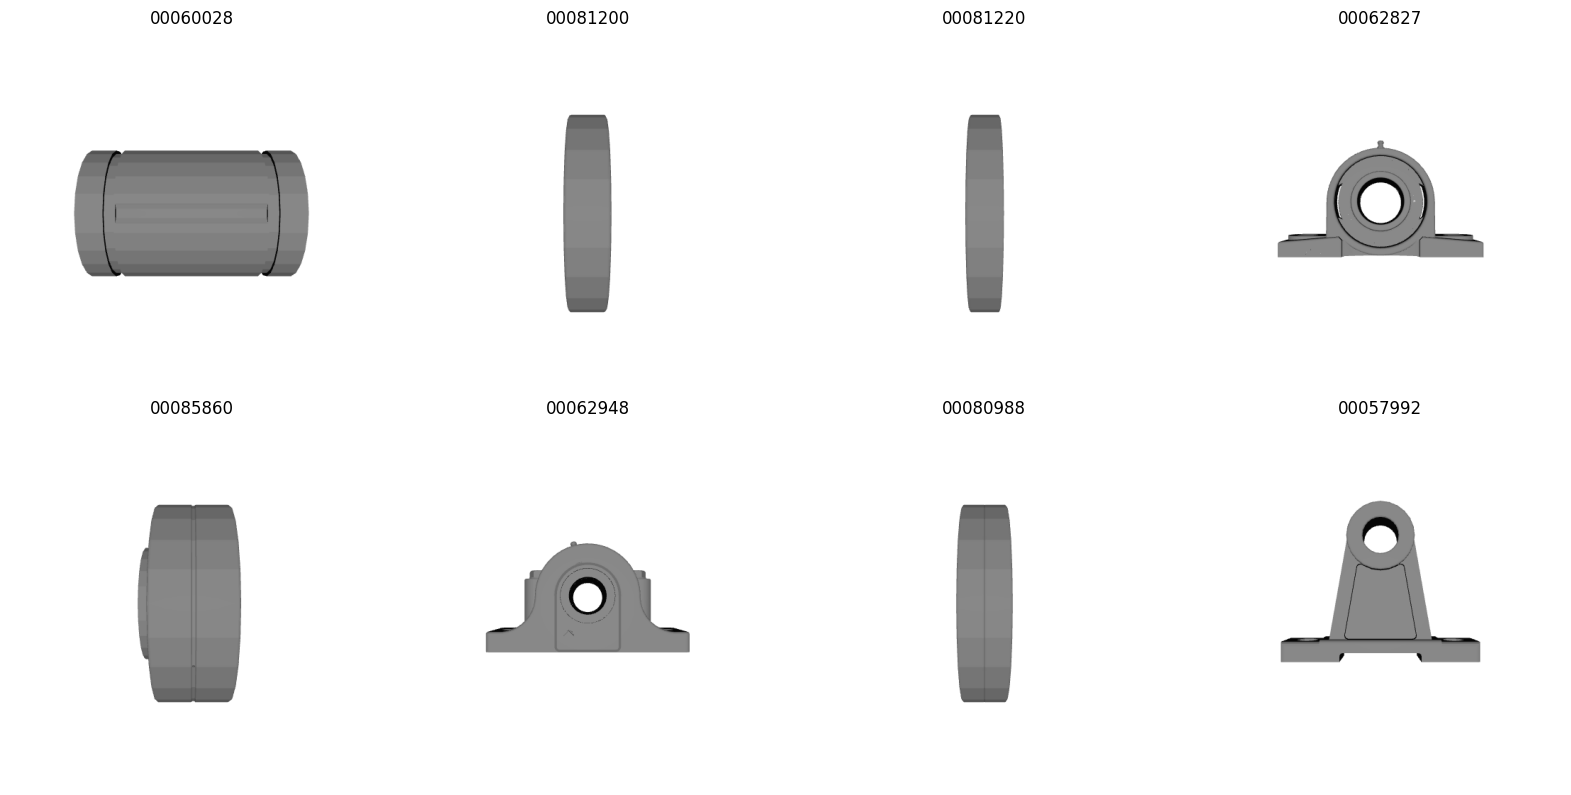

In [ ]:
import pyrender
import trimesh
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random
from pathlib import Path

bearing_dir = Path("/content/MCB_B/MCB_B/test/bearing")
obj_files = list(bearing_dir.glob("*.obj"))

def render_obj(path, size=512):
    mesh = trimesh.load(path, force="mesh")

    # Center and normalize
    mesh.apply_translation(-mesh.centroid)

    scale = mesh.extents.max()
    if scale > 0:
        mesh.apply_scale(1.5 / scale)

    render_mesh = pyrender.Mesh.from_trimesh(mesh, smooth=False)

    scene = pyrender.Scene()

    scene.add(render_mesh)

    # Camera
    camera = pyrender.PerspectiveCamera(
        yfov=np.pi / 3.0
    )

    camera_pose = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, 2.5],
        [0, 0, 0, 1]
    ])

    scene.add(camera, pose=camera_pose)

    # Lights
    light = pyrender.DirectionalLight(
        intensity=3.0
    )

    scene.add(light, pose=camera_pose)

    renderer = pyrender.OffscreenRenderer(size, size)

    color, depth = renderer.render(scene)

    renderer.delete()

    return Image.fromarray(color)


samples = random.sample(obj_files, 8)

plt.figure(figsize=(16, 8))

for i, path in enumerate(samples):
    img = render_obj(path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(path.stem)

plt.tight_layout()
plt.show()

What Classes Exist


In [ ]:
from pathlib import Path

base = Path("/content/MCB_B/MCB_B")

for split in ["train", "test"]:
    split_dir = base / split

    classes = sorted([
        p.name
        for p in split_dir.iterdir()
        if p.is_dir()
    ])

    print(f"\n{split.upper()} CLASSES ({len(classes)}):")
    print(classes)


TRAIN CLASSES (25):
['bearing', 'bushing', 'castors_and_wheels', 'clamp', 'disc', 'fitting', 'flange', 'fork_joint', 'gear', 'handles', 'hinge', 'hook', 'motor', 'nut', 'pin', 'plate', 'pulley', 'ring', 'rivet', 'rotor', 'screws_and_bolts', 'spring', 'stud', 'switch', 'washer']

TEST CLASSES (25):
['bearing', 'bushing', 'castors_and_wheels', 'clamp', 'disc', 'fitting', 'flange', 'fork_joint', 'gear', 'handles', 'hinge', 'hook', 'motor', 'nut', 'pin', 'plate', 'pulley', 'ring', 'rivet', 'rotor', 'screws_and_bolts', 'spring', 'stud', 'switch', 'washer']


In [ ]:
from collections import OrderedDict

test_dir = Path("/content/MCB_B/MCB_B/test")

class_counts = {}

for cls_dir in sorted(test_dir.iterdir()):
    if cls_dir.is_dir():
        count = len(list(cls_dir.glob("*.obj")))
        class_counts[cls_dir.name] = count

for cls, count in class_counts.items():
    print(f"{cls:25} {count}")

bearing                   104
bushing                   118
castors_and_wheels        72
clamp                     31
disc                      21
fitting                   349
flange                    79
fork_joint                9
gear                      102
handles                   350
hinge                     12
hook                      24
motor                     149
nut                       214
pin                       528
plate                     73
pulley                    61
ring                      110
rivet                     10
rotor                     93
screws_and_bolts          729
spring                    69
stud                      70
switch                    35
washer                    175


## 3.1 Install additional dependencies

In [ ]:
!pip uninstall -y pyopengl pyopengl-accelerate
!pip install -q PyOpenGL==3.1.5 PyOpenGL_accelerate==3.1.5

Found existing installation: PyOpenGL 3.1.0
Uninstalling PyOpenGL-3.1.0:
  Successfully uninstalled PyOpenGL-3.1.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.4/538.4 kB 17.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 84.3 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for PyOpenGL_accelerate
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (PyOpenGL_accelerate)


In [ ]:

!pip install -q open_clip_torch faiss-cpu scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00


## 3.2 Imports & config

In [ ]:

import os, io, json, random, itertools, math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt

import open_clip
import faiss

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

CLIP_MODEL_NAME = "ViT-B-32"
CLIP_PRETRAINED = "openai"   # real pretrained weights (downloaded fine in Colab)
EMBED_DIM = 512

# Materials we can *procedurally* apply on top of any rendered mesh.
MATERIAL_TINTS = {
    "metallic": (180, 182, 188),
    "plastic":  (60, 120, 200),
    "painted":  (200, 70, 60),
    "rusted":   (150, 100, 60),
}
MATERIAL_LIST = list(MATERIAL_TINTS.keys())
MATERIAL2ID = {m: i for i, m in enumerate(MATERIAL_LIST)}

# Size bins for the constraint parser's NUMERIC slot (discretized delta)
SIZE_SCALE_CHOICES = [0.7, 0.85, 1.0, 1.15, 1.3]   # 1.0 == reference scale


device: cuda


In [ ]:
import trimesh
import pyrender

def _make_procedural_texture(kind, size=256):
    rng = np.random.default_rng(abs(hash(kind)) % (2**32))
    if kind == "metallic":
        img = np.clip(205 + rng.integers(-10, 10, (size, size, 1)), 0, 255)
        img = np.repeat(img, 3, axis=2).astype(np.uint8)
        for _ in range(40):
            y = rng.integers(0, size)
            img[y:y+1, :] = np.clip(img[y:y+1, :].astype(int) + rng.integers(-15, 30), 0, 255)
    elif kind == "plastic":
        img = np.full((size, size, 3), (40, 90, 200), dtype=np.uint8)
        img = np.clip(img.astype(int) + rng.integers(-8, 8, (size, size, 3)), 0, 255).astype(np.uint8)
    elif kind == "aluminum":
        img = np.clip(220 + rng.integers(-8, 8, (size, size, 1)), 0, 255)
        img = np.repeat(img, 3, axis=2).astype(np.uint8)
    elif kind == "brass":
        img = np.full((size, size, 3), (200, 165, 60), dtype=np.uint8)
        img = np.clip(img.astype(int) + rng.integers(-10, 10, (size, size, 3)), 0, 255).astype(np.uint8)
    elif kind == "painted":
        img = np.full((size, size, 3), (25, 25, 28), dtype=np.uint8)
        grad = np.linspace(-10, 30, size).astype(int).reshape(1, size, 1)
        img = np.clip(img.astype(int) + grad, 0, 255).astype(np.uint8)
    elif kind == "rusted":
        img = np.full((size, size, 3), (130, 85, 55), dtype=np.uint8)
        # single brightness-only noise channel applied to all 3 -- avoids
        # independent per-channel noise producing random hues under UV smearing
        brightness_noise = rng.integers(-30, 30, (size, size, 1))
        img = np.clip(img.astype(int) + brightness_noise, 0, 255).astype(np.uint8)
        mask = rng.random((size, size)) > 0.94
        img[mask] = [95, 60, 40]
    else:
        img = np.full((size, size, 3), 200, dtype=np.uint8)
    return Image.fromarray(img, "RGB")

def _tint_texture(img, tint_rgb, strength=0.55):
    """Multiply-blend a color onto a loaded photo texture -- keeps the
    photo's shading/highlights but pushes its hue toward the target material
    color, so a pale real-world photo doesn't read as generic gray."""
    arr = np.array(img).astype(float)
    tint = np.array(tint_rgb, dtype=float)
    blended = arr * (1 - strength) + (arr / 255.0 * tint) * strength
    return Image.fromarray(np.clip(blended, 0, 255).astype(np.uint8))

MATERIAL_LIST_TEX = ["metallic", "plastic", "aluminum", "brass", "painted", "rusted"]

TEXTURE_PATHS = {
    "metallic": "/content/drive/MyDrive/textures/steel.jpg",
    "plastic":  "/content/drive/MyDrive/textures/plastic.jpeg",
    "rusted":   "/content/drive/MyDrive/textures/rusted.jpeg",
}
_TEXTURE_CACHE = {}
for kind in MATERIAL_LIST_TEX:
    if kind in TEXTURE_PATHS:
        img = Image.open(TEXTURE_PATHS[kind]).convert("RGB").resize((256, 256))
        if kind == "plastic":
            img = _tint_texture(img, (55, 120, 210))
        _TEXTURE_CACHE[kind] = img
    else:
        _TEXTURE_CACHE[kind] = _make_procedural_texture(kind)

def _simple_uv(mesh):
    v = mesh.vertices - mesh.vertices.mean(axis=0)
    cov = np.cov(v.T)
    _, vecs = np.linalg.eigh(cov)
    proj = v @ vecs[:, -2:]
    proj -= proj.min(axis=0)
    proj /= (proj.max(axis=0) + 1e-8)
    return proj

def apply_material_texture(mesh, material_kind, subdivisions=1):
    mesh = mesh.copy()
    for _ in range(subdivisions):
        mesh = mesh.subdivide()

    tex_img = _TEXTURE_CACHE[material_kind]
    uv = getattr(mesh.visual, "uv", None)
    if uv is None:
        uv = _simple_uv(mesh)
    tex_arr = np.array(tex_img)
    h, w = tex_arr.shape[:2]
    px = np.clip((uv[:, 0] * (w - 1)).astype(int), 0, w - 1)
    py = np.clip(((1 - uv[:, 1]) * (h - 1)).astype(int), 0, h - 1)
    vertex_colors = tex_arr[py, px]
    rgba = np.concatenate([vertex_colors, np.full((len(vertex_colors), 1), 255, dtype=np.uint8)], axis=1)
    mesh.visual = trimesh.visual.color.ColorVisuals(mesh, vertex_colors=rgba)
    return mesh

def _look_at(cam_pos, target=np.array([0, 0, 0]), up=np.array([0, 1, 0])):
    forward = (target - cam_pos)
    forward = forward / np.linalg.norm(forward)
    right = np.cross(forward, up)
    right = right / (np.linalg.norm(right) + 1e-8)
    true_up = np.cross(right, forward)

    pose = np.eye(4)
    pose[:3, 0] = right
    pose[:3, 1] = true_up
    pose[:3, 2] = -forward   # camera looks down -Z in pyrender/OpenGL convention
    pose[:3, 3] = cam_pos
    return pose

def render_obj_textured(path, material_kind="metallic", size=512, azimuth_deg=0.0):
    mesh = trimesh.load(path, force="mesh")
    mesh.apply_translation(-mesh.centroid)
    scale = mesh.extents.max()
    if scale > 0:
        mesh.apply_scale(1.5 / scale)
    mesh = apply_material_texture(mesh, material_kind)

    render_mesh = pyrender.Mesh.from_trimesh(mesh, smooth=True)
    scene = pyrender.Scene(bg_color=[245, 245, 245, 255], ambient_light=[0.25, 0.25, 0.25])
    scene.add(render_mesh)

    theta = np.radians(azimuth_deg)
    cam_pos = np.array([2.5 * np.sin(theta), 0.3, 2.5 * np.cos(theta)])
    cam_pose = _look_at(cam_pos)

    camera = pyrender.PerspectiveCamera(yfov=np.pi / 3.0)
    scene.add(camera, pose=cam_pose)
    scene.add(pyrender.DirectionalLight(intensity=1.6), pose=cam_pose)
    fill_pose = cam_pose.copy()
    fill_pose[:3, 3] = [-1.5, 1.5, 2.0]
    scene.add(pyrender.DirectionalLight(intensity=0.8), pose=fill_pose)

    renderer = pyrender.OffscreenRenderer(size, size)
    color, _ = renderer.render(scene)
    renderer.delete()
    return Image.fromarray(color)

/tmp/ipykernel_2662/1547160015.py:35: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(img, "RGB")


In [ ]:
from sklearn.cluster import KMeans

def _photo_to_palette(path, n_colors=4):
    img = Image.open(path).convert("RGB").resize((64, 64))
    pixels = np.array(img).reshape(-1, 3)
    kmeans = KMeans(n_clusters=n_colors, n_init=4, random_state=0).fit(pixels)
    counts = np.bincount(kmeans.labels_)
    order = np.argsort(-counts)
    return kmeans.cluster_centers_[order].astype(int)  # sorted most -> least common

def _make_texture_from_palette(palette, size=256):
    rng = np.random.default_rng(0)
    base = palette[0]
    img = np.tile(base, (size, size, 1)).astype(int)
    # scatter patches of the secondary colors on top, like real material variation
    for color in palette[1:]:
        n_patches = rng.integers(15, 30)
        for _ in range(n_patches):
            cx, cy = rng.integers(0, size, 2)
            r = rng.integers(8, 25)
            yy, xx = np.ogrid[:size, :size]
            mask = (xx - cx)**2 + (yy - cy)**2 <= r**2
            img[mask] = color
    img = np.clip(img + rng.integers(-10, 10, (size, size, 1)), 0, 255)
    return Image.fromarray(img.astype(np.uint8), "RGB")

rust_palette = _photo_to_palette("/content/drive/MyDrive/textures/rusted.jpeg")
_TEXTURE_CACHE["rusted"] = _make_texture_from_palette(rust_palette)

/tmp/ipykernel_2662/3050963233.py:25: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(img.astype(np.uint8), "RGB")


In [ ]:
print("obj_files defined:", "obj_files" in globals(), " length:", len(obj_files) if "obj_files" in globals() else "N/A")
sample_obj = obj_files[0]
print("sample_obj:", sample_obj)

obj_files defined: True  length: 104
sample_obj: /content/MCB_B/MCB_B/test/bearing/00064135.obj


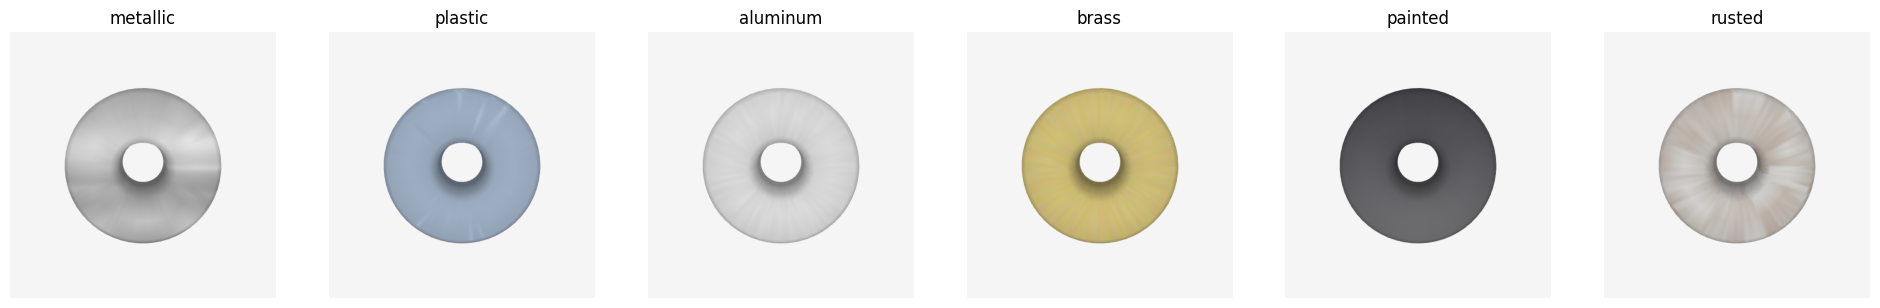

In [ ]:
material_keys = list(_TEXTURE_CACHE.keys())
fig, axes = plt.subplots(1, len(material_keys), figsize=(4*len(material_keys), 4))
for ax, kind in zip(axes, material_keys):
    ax.imshow(render_obj_textured(sample_obj, kind))
    ax.set_title(kind); ax.axis("off")
plt.show()

In [ ]:
mesh = trimesh.load(sample_obj, force="mesh")
print("vertices:", len(mesh.vertices), "faces:", len(mesh.faces))

vertices: 517 faces: 1034



## 3.3 Folder / output analysis (what each dataset actually gives us)

Quick recap of what we found when probing the two sources in your notebook,
which drives the design choices above:

| Source | Path pattern | Input | Output / fields | Usable for |
|---|---|---|---|---|
| InVar-100 (HF) | `invar[i]` | index | `{'image': PIL.Image}` only | unlabeled gallery / distractors |
| MCB_B | `MCB_B/MCB_B/{train,test}/<class>/<id>.obj` | mesh id | class = folder name (25 classes) | triplet construction (below) |

We reuse this to build `class -> [obj paths]` maps for both splits.


In [ ]:

assert 'base' in globals(), "Run the MCB_B loading cells from your original notebook first."
assert 'render_obj' in globals(), "Run the MCB_B render_obj() cell from your original notebook first."

def index_mcb(base_path, split):
    split_dir = base_path / split
    out = {}
    for cls_dir in sorted(split_dir.iterdir()):
        if cls_dir.is_dir():
            out[cls_dir.name] = sorted(cls_dir.glob("*.obj"))
    return out

mcb_train_index = index_mcb(base, "train")
mcb_test_index  = index_mcb(base, "test")

# keep only classes with enough instances to form a proper held-out split
USABLE_CLASSES = [c for c in mcb_train_index
                   if len(mcb_train_index[c]) >= 4 and len(mcb_test_index.get(c, [])) >= 2]
print(f"{len(USABLE_CLASSES)} usable classes:", USABLE_CLASSES)


25 usable classes: ['bearing', 'bushing', 'castors_and_wheels', 'clamp', 'disc', 'fitting', 'flange', 'fork_joint', 'gear', 'handles', 'hinge', 'hook', 'motor', 'nut', 'pin', 'plate', 'pulley', 'ring', 'rivet', 'rotor', 'screws_and_bolts', 'spring', 'stud', 'switch', 'washer']


## 3.4 Procedural triplet construction (renders + synthetic modification text)

In [ ]:
# swap the old 4-material list for your new textured set
MATERIAL_LIST = MATERIAL_LIST_TEX  # ["metallic", "plastic", "aluminum", "brass", "painted", "rusted"]
MATERIAL2ID = {m: i for i, m in enumerate(MATERIAL_LIST)}

def render_variant(obj_path, scale_factor=1.0, material="metallic", size=128):
    '''Re-render an MCB_B mesh at a controlled scale + REAL material texture
    (replaces the old PIL post-hoc tint). Random azimuth per call gives the
    model some viewpoint robustness instead of always seeing the same angle.'''
    az = random.uniform(0, 360)
    img = render_obj_textured(obj_path, material_kind=material, size=size, azimuth_deg=az)

    if scale_factor != 1.0:
        new_size = max(8, int(size * min(scale_factor, 1.0)))
        resized = img.resize((new_size, new_size))
        canvas = Image.new("RGB", (size, size), (245, 245, 245))
        off = (size - new_size) // 2
        canvas.paste(resized, (off, off))
        if scale_factor > 1.0:
            zoom_size = int(size * scale_factor)
            zoomed = img.resize((zoom_size, zoom_size))
            left = (zoom_size - size) // 2
            canvas = zoomed.crop((left, left, left + size, left + size))
        img = canvas
    return img


def make_modification_text(cls, mat_to, scale_to):
    part = cls.replace("_", " ")

    size_word = (
        "smaller"
        if scale_to < 0.98
        else "larger"
        if scale_to > 1.02
        else "the same size"
    )

    if size_word == "the same size":
        templates = [
            f"same {part}, but {mat_to}",
            f"find a similar {part} with {mat_to} material",
            f"keep the same {part} shape, but make it {mat_to}",
            f"retrieve another {part} that is {mat_to}",
        ]
    else:
        templates = [
            f"same {part}, but {size_word} and {mat_to}",
            f"find a similar {part} that is {size_word} and {mat_to}",
            f"keep the {part} type, but make it {size_word} with {mat_to} material",
            f"retrieve another {part} with a {size_word} size and {mat_to} finish",
        ]

    return random.choice(templates)


def build_triplets(index, classes, n_per_class, seed_offset=0):
    triplets = []
    rng = random.Random(SEED + seed_offset)
    for cls in classes:
        paths = index[cls]
        for i in range(n_per_class):
            obj_path = rng.choice(paths)
            mat_from = rng.choice(MATERIAL_LIST)
            mat_to = rng.choice(MATERIAL_LIST)
            scale_to = rng.choice(SIZE_SCALE_CHOICES)
            triplets.append({
                "obj_path": str(obj_path), "cls": cls,
                "mat_from": mat_from, "mat_to": mat_to,
                "scale_from": 1.0, "scale_to": scale_to,
                "text": make_modification_text(cls, mat_to, scale_to),
            })
    return triplets

N_PER_CLASS_TRAIN = 60
N_PER_CLASS_TEST  = 10

train_triplets = build_triplets(mcb_train_index, USABLE_CLASSES, N_PER_CLASS_TRAIN, seed_offset=1)
test_triplets  = build_triplets(mcb_test_index,  USABLE_CLASSES, N_PER_CLASS_TEST,  seed_offset=2)
print(f"train triplets: {len(train_triplets)}   test triplets: {len(test_triplets)}")

distractor_images = []
print(f"gallery = {len(test_triplets)} MCB target images")

train triplets: 1500   test triplets: 250
gallery = 250 MCB target images


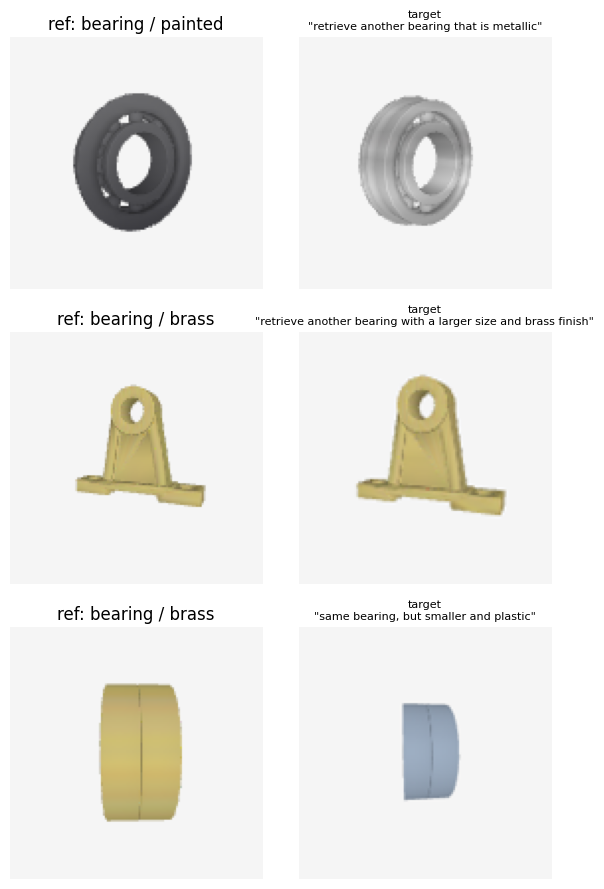

In [ ]:

# sanity-check a few rendered triplets
fig, axes = plt.subplots(3, 2, figsize=(6, 9))
for row, t in enumerate(train_triplets[:3]):
    ref_img = render_variant(t["obj_path"], t["scale_from"], t["mat_from"])
    tgt_img = render_variant(t["obj_path"], t["scale_to"], t["mat_to"])
    axes[row, 0].imshow(ref_img); axes[row, 0].set_title(f"ref: {t['cls']} / {t['mat_from']}"); axes[row, 0].axis("off")
    axes[row, 1].imshow(tgt_img); axes[row, 1].set_title(f"target\n\"{t['text']}\"", fontsize=8); axes[row, 1].axis("off")
plt.tight_layout(); plt.show()



## 4. IC-CIR architecture

Implements Figure 1 exactly:

`reference image -> OpenCLIP visual encoder -> {global branch (6.2), part/structure branch (6.3)}`
`modification text -> OpenCLIP text encoder + constraint parser (6.4) -> KEEP/MODIFY/NUMERIC`
`-> attribute & constraint disentanglement (6.5) -> unified prototype composition (6.6)`
`-> composed query embedding (6.7) -> top-K retrieval -> constraint-aware reranker (6.8)`


In [ ]:

def load_backbone(model_name=CLIP_MODEL_NAME, pretrained=CLIP_PRETRAINED, device=DEVICE):
    model, _, preprocess = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
    tokenizer = open_clip.get_tokenizer(model_name)
    model = model.to(device).eval()
    for p in model.parameters():
        p.requires_grad_(False)   # 6.1: frozen backbone, only IC-CIR modules are trained
    return model, preprocess, tokenizer


class CLIPFeatureExtractor(nn.Module):
    """
    Uses OpenCLIP's official encode_image() for the global feature.

    Patch tokens are extracted separately for the structure branch.
    """

    def __init__(self, clip_model):
        super().__init__()
        self.clip = clip_model

    @torch.no_grad()
    def encode_image_tokens(self, images):

        visual = self.clip.visual

        # ----------------------------------------------------
        # 1. GLOBAL FEATURE
        # Use OpenCLIP's official implementation.
        # Do NOT manually reconstruct the CLS embedding.
        # ----------------------------------------------------
        global_feat = self.clip.encode_image(
            images,
            normalize=False
        ).float()

        # ----------------------------------------------------
        # 2. PATCH FEATURES
        # OpenCLIP ViT internal forward
        # ----------------------------------------------------

        x = visual.conv1(images)

        # B,C,H,W -> B,N,C
        x = x.reshape(
            x.shape[0],
            x.shape[1],
            -1
        ).permute(0, 2, 1)

        # CLS token
        cls_token = visual.class_embedding.to(x.dtype)

        cls_token = cls_token + torch.zeros(
            x.shape[0],
            1,
            x.shape[-1],
            dtype=x.dtype,
            device=x.device
        )

        x = torch.cat(
            [cls_token, x],
            dim=1
        )

        x = x + visual.positional_embedding.to(x.dtype)

        if hasattr(visual, "patch_dropout"):
            x = visual.patch_dropout(x)

        x = visual.ln_pre(x)

        # IMPORTANT:
        # current OpenCLIP transformer receives B,N,D
        x = visual.transformer(x)

        patch_tok = x[:, 1:, :]

        patch_tok = visual.ln_post(patch_tok)

        if visual.proj is not None:
            patch_feat = patch_tok @ visual.proj
        else:
            patch_feat = patch_tok

        return global_feat, patch_feat.float()

    @torch.no_grad()
    def encode_text(self, tokens):

        return self.clip.encode_text(
            tokens,
            normalize=False
        ).float()


class PartStructureBranch(nn.Module):
    '''6.3 — attention-pools patch tokens into a part/structure-aware vector,
    instead of relying only on the single global CLIP embedding.'''
    def __init__(self, dim, n_heads=4):
        super().__init__()
        self.query = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.attn = nn.MultiheadAttention(dim, n_heads, batch_first=True)
        self.proj = nn.Linear(dim, dim)

    def forward(self, patch_tokens):
        b = patch_tokens.shape[0]
        q = self.query.expand(b, -1, -1)
        out, attn_w = self.attn(q, patch_tokens, patch_tokens)
        return self.proj(out.squeeze(1)), attn_w.squeeze(1)


class ConstraintParser(nn.Module):
    '''6.4 — KEEP / MODIFY / NUMERIC. Slot ids are extracted with a simple
    rule-based parser over our templated text (regex-equivalent lookups since
    text is templated); free-form text would need a learned slot tagger
    (e.g. fine-tuned on FineCIR-style parsing [3]) as noted in Section 6.4.'''
    def __init__(self, text_dim, n_materials, n_size_bins):
        super().__init__()
        self.material_emb = nn.Embedding(n_materials + 1, text_dim)
        self.size_emb = nn.Embedding(n_size_bins + 1, text_dim)
        self.keep_flag_proj = nn.Linear(2, text_dim)
        self.fuse = nn.Sequential(nn.Linear(text_dim * 4, text_dim), nn.GELU(), nn.Linear(text_dim, text_dim))

    def forward(self, clip_text_feat, material_id, size_bin, keep_flags):
        m = self.material_emb(material_id)
        s = self.size_emb(size_bin)
        k = self.keep_flag_proj(keep_flags.float())
        fused = self.fuse(torch.cat([clip_text_feat, m, s, k], dim=-1))
        return fused


class Disentangler(nn.Module):
    '''6.5 — COMBINER-inspired: separate structure / material / size subspaces
    instead of one entangled vector.'''
    def __init__(self, dim):
        super().__init__()
        self.names = ["structure", "material", "size"]
        self.heads = nn.ModuleList([nn.Sequential(nn.Linear(dim, dim), nn.GELU(), nn.Linear(dim, dim)) for _ in self.names])

    def forward(self, feat):
        return {name: head(feat) for name, head in zip(self.names, self.heads)}


class PrototypeComposer(nn.Module):
    '''6.6 — cross-modal unified prototype dictionary + attention composition.'''
    def __init__(self, dim, n_prototypes=16):
        super().__init__()
        self.prototypes = nn.Parameter(torch.randn(n_prototypes, dim) * 0.02)
        self.q_proj = nn.Linear(dim, dim)

    def forward(self, feat):
        q = self.q_proj(feat)
        attn = F.softmax(q @ self.prototypes.t() / (feat.shape[-1] ** 0.5), dim=-1)
        return attn @ self.prototypes + feat


class ICCIR(nn.Module):
    def __init__(self, dim=EMBED_DIM, n_materials=len(MATERIAL_LIST), n_size_bins=len(SIZE_SCALE_CHOICES)):
        super().__init__()
        self.part_branch = PartStructureBranch(dim)
        self.parser = ConstraintParser(dim, n_materials, n_size_bins)
        self.disentangler = Disentangler(dim)
        self.composer_struct = PrototypeComposer(dim)
        self.composer_material = PrototypeComposer(dim)
        self.composer_size = PrototypeComposer(dim)
        self.keep_gate = nn.Sequential(nn.Linear(dim * 2, dim), nn.Sigmoid())
        self.fuse_out = nn.Sequential(nn.Linear(dim * 3, dim), nn.GELU(), nn.Linear(dim, dim))
        self.material_head = nn.Linear(dim, n_materials)   # for L_mod
        self.size_head = nn.Linear(dim, 1)                  # for L_mod

    def encode_reference(self, ref_global, ref_patch):
        '''6.2 + 6.3 -> 6.5 (visual side only); reused for target/gallery too.'''
        ref_part, part_attn = self.part_branch(ref_patch)
        vis_sub = self.disentangler(ref_global + ref_part)
        return vis_sub, part_attn

    def forward(self, ref_global, ref_patch, text_global, material_id, size_bin, keep_flags):
        vis_sub, part_attn = self.encode_reference(ref_global, ref_patch)
        text_fused = self.parser(text_global, material_id, size_bin, keep_flags)
        txt_sub = self.disentangler(text_fused)

        composed_struct = self.composer_struct(txt_sub["structure"])
        composed_material = self.composer_material(txt_sub["material"])
        composed_size = self.composer_size(txt_sub["size"])

        gate = self.keep_gate(torch.cat([vis_sub["structure"], composed_struct], dim=-1))
        kept_struct = gate * vis_sub["structure"] + (1 - gate) * composed_struct  # 6.4 KEEP channel

        composed_query = self.fuse_out(torch.cat([kept_struct, composed_material, composed_size], dim=-1))
        composed_query = F.normalize(composed_query, dim=-1)

        return {
            "composed_query": composed_query,
            "part_attn": part_attn,
            "vis_sub": vis_sub,
            "pred_material_logits": self.material_head(composed_query),
            "pred_size_delta": self.size_head(composed_query),
        }


class Reranker(nn.Module):
    '''6.8 — rescoring top-K using explicit constraint match, not just cosine sim.'''
    def __init__(self, dim, n_materials):
        super().__init__()
        self.cand_material_head = nn.Linear(dim, n_materials)
        self.cand_size_head = nn.Linear(dim, 1)
        self.score_mlp = nn.Sequential(nn.Linear(4, 16), nn.GELU(), nn.Linear(16, 1))

    def forward(self, sim_score, cand_global_feat, req_material_id, req_size_delta):
        mat_logp = F.log_softmax(self.cand_material_head(cand_global_feat), dim=-1)
        mat_match = mat_logp.gather(1, req_material_id.unsqueeze(1)).squeeze(1)
        size_pred = self.cand_size_head(cand_global_feat).squeeze(1)
        size_penalty = -((size_pred - req_size_delta) ** 2)
        feats = torch.stack([sim_score, mat_match, size_penalty, sim_score * mat_match], dim=-1)
        return self.score_mlp(feats).squeeze(-1)


## 5. Losses (Section 7)

In [ ]:

def info_nce(query, target, temperature=0.07):
    query = F.normalize(query, dim=-1); target = F.normalize(target, dim=-1)
    logits = query @ target.t() / temperature
    labels = torch.arange(query.shape[0], device=query.device)
    return F.cross_entropy(logits, labels)

def preservation_loss(vis_struct_sub, target_struct_sub, keep_mask):
    cos = F.cosine_similarity(vis_struct_sub, target_struct_sub, dim=-1)
    return (keep_mask.float() * (1 - cos)).mean()

def modification_loss(pred_material_logits, gt_material_id, pred_size_delta, gt_size_delta):
    return F.cross_entropy(pred_material_logits, gt_material_id) + F.mse_loss(pred_size_delta.squeeze(-1), gt_size_delta)

def counterfactual_loss(query, target, wrong_query, margin=0.2):
    pos = F.cosine_similarity(query, target, dim=-1)
    neg = F.cosine_similarity(wrong_query, target, dim=-1)
    return F.relu(neg - pos + margin).mean()


## 6. Load backbone + pre-encode all images/text

In [ ]:
from tqdm.auto import tqdm

clip_model, clip_preprocess, tokenizer = load_backbone()

extractor = CLIPFeatureExtractor(clip_model)


def encode_pils(pil_imgs, batch_size=32, desc="Encoding images"):

    globals_, patches_ = [], []

    for i in tqdm(
        range(0, len(pil_imgs), batch_size),
        desc=desc,
        total=(len(pil_imgs) + batch_size - 1) // batch_size
    ):

        batch = torch.stack([
            clip_preprocess(im.convert("RGB"))
            for im in pil_imgs[i:i + batch_size]
        ]).to(DEVICE)

        with torch.inference_mode():
            g, p = extractor.encode_image_tokens(batch)

        globals_.append(g.cpu())
        patches_.append(p.cpu())

    return torch.cat(globals_), torch.cat(patches_)


def encode_texts(texts, batch_size=64, desc="Encoding text"):

    out = []

    for i in tqdm(
        range(0, len(texts), batch_size),
        desc=desc,
        total=(len(texts) + batch_size - 1) // batch_size
    ):

        toks = tokenizer(texts[i:i + batch_size]).to(DEVICE)

        with torch.inference_mode():
            out.append(extractor.encode_text(toks).cpu())

    return torch.cat(out)


def prep_split(triplets, split_name="train"):

    print(f"\nRendering {split_name} reference images...")

    ref_imgs = [
        render_variant(
            t["obj_path"],
            t["scale_from"],
            t["mat_from"]
        )
        for t in tqdm(
            triplets,
            desc=f"{split_name}: render references"
        )
    ]

    print(f"\nRendering {split_name} target images...")

    tgt_imgs = [
        render_variant(
            t["obj_path"],
            t["scale_to"],
            t["mat_to"]
        )
        for t in tqdm(
            triplets,
            desc=f"{split_name}: render targets"
        )
    ]

    print(f"\nEncoding {split_name} reference images...")

    ref_g, ref_p = encode_pils(
        ref_imgs,
        desc=f"{split_name}: CLIP reference"
    )

    print(f"\nEncoding {split_name} target images...")

    tgt_g, tgt_p = encode_pils(
        tgt_imgs,
        desc=f"{split_name}: CLIP target"
    )

    print(f"\nEncoding {split_name} modification text...")

    txt_g = encode_texts(
        [t["text"] for t in triplets],
        desc=f"{split_name}: CLIP text"
    )

    material_id = torch.tensor([
        MATERIAL2ID[t["mat_to"]]
        for t in triplets
    ])

    size_delta = torch.tensor([
        t["scale_to"] - t["scale_from"]
        for t in triplets
    ], dtype=torch.float32)

    size_bin = torch.tensor([
        SIZE_SCALE_CHOICES.index(t["scale_to"])
        for t in triplets
    ])

    keep_flags = torch.zeros(
        len(triplets),
        2
    )

    print(f"\n{split_name} encoding complete.")

    return dict(
        ref_g=ref_g,
        ref_p=ref_p,
        tgt_g=tgt_g,
        tgt_p=tgt_p,
        txt_g=txt_g,
        material_id=material_id,
        size_delta=size_delta,
        size_bin=size_bin,
        keep_flags=keep_flags,
        imgs=(ref_imgs, tgt_imgs)
    )


print("Encoding train split...")
train_enc = prep_split(
    train_triplets,
    split_name="TRAIN"
)

print("\nEncoding test split...")
test_enc = prep_split(
    test_triplets,
    split_name="TEST"
)


print("\nBuilding gallery...")

gallery_target_g, _ = encode_pils(
    [im for im in test_enc["imgs"][1]],
    desc="Gallery encoding"
)

gallery_g = gallery_target_g

gallery_is_true_target = torch.ones(
    len(test_triplets),
    dtype=torch.bool
)

print("\nMCB-only gallery size:", gallery_g.shape)

/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Encoding train split...

Rendering TRAIN reference images...


TRAIN: render references:   0%|          | 0/1500 [00:00<?, ?it/s]


Rendering TRAIN target images...


TRAIN: render targets:   0%|          | 0/1500 [00:00<?, ?it/s]

...


Encoding TEST modification text...


TEST: CLIP text:   0%|          | 0/4 [00:00<?, ?it/s]


TEST encoding complete.

Building gallery...


Gallery encoding:   0%|          | 0/8 [00:00<?, ?it/s]


MCB-only gallery size: torch.Size([250, 512])


SANITYY

In [ ]:
import torch
import torch.nn.functional as F

sample_imgs = train_enc["imgs"][0][:8]

batch = torch.stack([
    clip_preprocess(im.convert("RGB"))
    for im in sample_imgs
]).to(DEVICE)

with torch.no_grad():

    official = clip_model.encode_image(
        batch,
        normalize=True
    )

    custom_g, custom_p = extractor.encode_image_tokens(batch)

    custom_g = F.normalize(custom_g, dim=-1)

    cos = F.cosine_similarity(
        official,
        custom_g,
        dim=-1
    )

print("Official vs extractor cosine:")
print(cos)

print("Mean:", cos.mean().item())
print("Patch shape:", custom_p.shape)

Official vs extractor cosine:
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       device='cuda:0')
Mean: 1.0
Patch shape: torch.Size([8, 49, 512])


In [ ]:
g = F.normalize(
    test_enc["tgt_g"],
    dim=-1
)

sim = g @ g.T

mask = ~torch.eye(
    len(g),
    dtype=torch.bool,
    device=g.device
)

vals = sim[mask]

print("Different-image cosine mean:", vals.mean().item())
print("Different-image cosine std :", vals.std().item())
print("Min:", vals.min().item())
print("Max:", vals.max().item())

Different-image cosine mean: 0.8446820378303528
Different-image cosine std : 0.04266428202390671
Min: 0.6059970855712891
Max: 0.9904080033302307


## 7. Train IC-CIR (+ an ablation-ready training loop)

epoch   0  loss=3.3415
epoch  25  loss=0.9317
epoch  50  loss=0.5018
epoch  75  loss=0.3725
epoch 100  loss=0.3093
epoch 125  loss=0.2595
epoch 150  loss=0.2235
epoch 175  loss=0.2320
epoch 200  loss=0.1749
epoch 225  loss=0.1702
epoch 250  loss=0.1762
epoch 275  loss=0.1727
epoch 300  loss=0.1660
epoch 325  loss=0.1697
epoch 350  loss=0.1420
epoch 375  loss=0.1838
epoch 400  loss=0.1892
epoch 425  loss=0.1556
epoch 450  loss=0.1378
epoch 475  loss=0.1402
epoch 500  loss=0.1658
epoch 525  loss=0.1604
epoch 550  loss=0.1499
epoch 575  loss=0.1355
epoch 600  loss=0.1438
epoch 625  loss=0.1410
epoch 650  loss=0.1378
epoch 675  loss=0.1481
epoch 700  loss=0.1379
epoch 725  loss=0.1242
epoch 750  loss=0.1259
epoch 775  loss=0.1284
epoch 800  loss=0.1204
epoch 825  loss=0.1196
epoch 850  loss=0.1233
epoch 875  loss=0.1206
epoch 900  loss=0.1336
epoch 925  loss=0.1326
epoch 950  loss=0.1293
epoch 975  loss=0.1322
epoch 999  loss=0.1329
Overfit sanity check (10 examples): self-retrieval accura

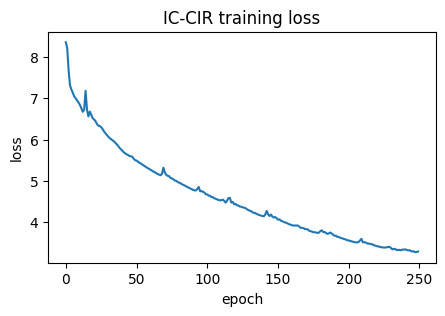

In [ ]:
def train_iccir(train_enc, n_epochs=250, lr=1e-3, use_pres=True, use_mod=True, use_cf=True, seed=0):
    torch.manual_seed(seed)
    model = ICCIR().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    ref_g, ref_p = train_enc["ref_g"].to(DEVICE), train_enc["ref_p"].to(DEVICE)
    tgt_g, tgt_p = train_enc["tgt_g"].to(DEVICE), train_enc["tgt_p"].to(DEVICE)
    txt_g = train_enc["txt_g"].to(DEVICE)
    material_id = train_enc["material_id"].to(DEVICE)
    size_bin = train_enc["size_bin"].to(DEVICE)
    size_delta = train_enc["size_delta"].to(DEVICE)
    keep_flags = train_enc["keep_flags"].to(DEVICE)
    n = ref_g.shape[0]

    history = []
    for epoch in range(n_epochs):
        out = model(ref_g, ref_p, txt_g, material_id, size_bin, keep_flags)
        q = out["composed_query"]
        tgt_part, _ = model.part_branch(tgt_p)
        tgt_sub = model.disentangler(tgt_g + tgt_part)

        loss = info_nce(q, F.normalize(tgt_g, dim=-1))
        if use_pres:
            loss = loss + 0.5 * preservation_loss(out["vis_sub"]["structure"], tgt_sub["structure"], torch.ones(n, device=DEVICE))
        if use_mod:
            loss = loss + 0.5 * modification_loss(out["pred_material_logits"], material_id, out["pred_size_delta"], size_delta)
        if use_cf:
            perm = torch.randperm(n, device=DEVICE)
            out_cf = model(ref_g[perm], ref_p[perm], txt_g, material_id, size_bin, keep_flags)
            loss = loss + 0.3 * counterfactual_loss(q, F.normalize(tgt_g, dim=-1), out_cf["composed_query"])

        opt.zero_grad(); loss.backward(); opt.step()
        history.append(loss.item())
        if epoch % 25 == 0 or epoch == n_epochs - 1:
            print(f"epoch {epoch:3d}  loss={loss.item():.4f}")
    return model, history

# --- Sanity check: can the model overfit a tiny slice of its own training data? ---
# If self-retrieval accuracy isn't near 1.0, there's a bug in the loss/label
# wiring — fix that before trusting anything trained on the full set below.
tiny_enc = {k: (v[:10] if torch.is_tensor(v) else v) for k, v in train_enc.items() if k != "imgs"}
tiny_enc["imgs"] = (train_enc["imgs"][0][:10], train_enc["imgs"][1][:10])
tiny_model, tiny_hist = train_iccir(
    tiny_enc,
    n_epochs=1000,
    lr=2e-3
)
with torch.no_grad():
    q = tiny_model(tiny_enc["ref_g"].to(DEVICE), tiny_enc["ref_p"].to(DEVICE),
                    tiny_enc["txt_g"].to(DEVICE), tiny_enc["material_id"].to(DEVICE),
                    tiny_enc["size_bin"].to(DEVICE), tiny_enc["keep_flags"].to(DEVICE))["composed_query"]
    tgt = F.normalize(tiny_enc["tgt_g"].to(DEVICE), dim=-1)
    sims = q @ tgt.t()
    correct = (sims.argmax(dim=-1) == torch.arange(10, device=DEVICE)).float().mean()
print(f"Overfit sanity check (10 examples): self-retrieval accuracy = {correct.item():.2f} (should be close to 1.0)")

print("=== Training full IC-CIR (all losses) ===")
model_full, hist_full = train_iccir(train_enc)

plt.figure(figsize=(5,3)); plt.plot(hist_full); plt.title("IC-CIR training loss"); plt.xlabel("epoch"); plt.ylabel("loss"); plt.show()

## 8. Baselines (B1–B4) + ablations, matching Section 4 of the proposal

In [ ]:

class SimpleCombiner(nn.Module):
    '''B4 — proxy for Baldrati et al.'s Combiner [2]: a plain learned MLP
    fusing global CLIP image + text features, no part branch / no constraints.'''
    def __init__(self, dim=EMBED_DIM):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(dim * 2, dim), nn.GELU(), nn.Linear(dim, dim))
    def forward(self, img_g, txt_g):
        return F.normalize(self.mlp(torch.cat([img_g, txt_g], dim=-1)), dim=-1)

def train_combiner(train_enc, n_epochs=30, lr=1e-3):
    torch.manual_seed(0)
    combiner = SimpleCombiner().to(DEVICE)
    opt = torch.optim.Adam(combiner.parameters(), lr=lr)
    ref_g, txt_g, tgt_g = train_enc["ref_g"].to(DEVICE), train_enc["txt_g"].to(DEVICE), train_enc["tgt_g"].to(DEVICE)
    for epoch in range(n_epochs):
        q = combiner(ref_g, txt_g)
        loss = info_nce(q, F.normalize(tgt_g, dim=-1))
        opt.zero_grad(); loss.backward(); opt.step()
    return combiner

print("=== Training B4 (SimpleCombiner baseline) ===")
combiner_model = train_combiner(train_enc)

print("=== Training IC-CIR ablations ===")
model_no_pres, _ = train_iccir(train_enc, use_pres=False, use_mod=True,  use_cf=True)
model_no_mod,  _ = train_iccir(train_enc, use_pres=True,  use_mod=False, use_cf=True)
model_no_cf,   _ = train_iccir(train_enc, use_pres=True,  use_mod=True,  use_cf=False)

def b1_image_only(ref_g, **kw):
    return F.normalize(ref_g, dim=-1)

def b2_text_only(txt_g, **kw):
    return F.normalize(txt_g, dim=-1)

def b3_weighted_fusion(ref_g, txt_g, alpha=0.5, **kw):
    return F.normalize(alpha * F.normalize(ref_g, dim=-1) + (1 - alpha) * F.normalize(txt_g, dim=-1), dim=-1)


=== Training B4 (SimpleCombiner baseline) ===
=== Training IC-CIR ablations ===
epoch   0  loss=8.3221
epoch  25  loss=6.0477
epoch  50  loss=5.3235
epoch  75  loss=4.9062
epoch 100  loss=4.4938
epoch 125  loss=4.1826
epoch 150  loss=3.9157
epoch 175  loss=3.6519
epoch 200  loss=3.4100
epoch 225  loss=3.2629
epoch 249  loss=3.1528
epoch   0  loss=7.4428
epoch  25  loss=5.5107
epoch  50  loss=4.7724
epoch  75  loss=4.3486
epoch 100  loss=4.0626
epoch 125  loss=3.7688
epoch 150  loss=3.5450
epoch 175  loss=3.3020
epoch 200  loss=3.1866
epoch 225  loss=2.9537
epoch 249  loss=2.8511
epoch   0  loss=8.3015
epoch  25  loss=6.2001
epoch  50  loss=5.4091
epoch  75  loss=4.9907
epoch 100  loss=4.6648
epoch 125  loss=4.3564
epoch 150  loss=4.1156
epoch 175  loss=3.7847
epoch 200  loss=3.5386
epoch 225  loss=3.4352
epoch 249  loss=3.2133


**RERANKER**

In [ ]:
# ============================================================
# SAFE CONSTRAINT-AWARE RESIDUAL RERANKER
# ============================================================
#
# Key idea:
#   DO NOT replace the IC-CIR similarity score.
#   Only make small adjustments based on explicit constraints.
#
# final_score =
#     base_similarity
#     + material_bonus
#     - size_penalty
#
# This is much safer than a free MLP reranker.
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Helper: try to fetch candidate metadata
# ------------------------------------------------------------

def _get_first_existing(d, names):
    for name in names:
        if name in d:
            return d[name]
    return None


# ------------------------------------------------------------
# Inspect available metadata
# ------------------------------------------------------------

print("test_enc keys:")
print(test_enc.keys())

print("\ntrain_enc keys:")
print(train_enc.keys())


# ------------------------------------------------------------
# Candidate/gallery metadata
#
# We expect gallery rows to correspond to test targets.
# Therefore candidate metadata should normally come from
# the target side of test_enc.
# ------------------------------------------------------------

gallery_material = _get_first_existing(
    test_enc,
    [
        "target_material_id",
        "tgt_material_id",
        "material_id"
    ]
)

gallery_scale = _get_first_existing(
    test_enc,
    [
        "target_scale",
        "scale_to",
        "tgt_scale",
        "target_size",
        "size_to"
    ]
)

reference_scale = _get_first_existing(
    test_enc,
    [
        "reference_scale",
        "scale_from",
        "ref_scale",
        "source_scale",
        "size_from"
    ]
)

requested_delta = _get_first_existing(
    test_enc,
    [
        "size_delta",
        "delta_size",
        "scale_delta"
    ]
)


if gallery_material is None:
    raise KeyError(
        "Could not find gallery material metadata in test_enc. "
        "Expected something like material_id / target_material_id."
    )

if requested_delta is None:
    raise KeyError(
        "Could not find size_delta in test_enc."
    )


gallery_material = gallery_material.to(DEVICE)
requested_delta = requested_delta.float().to(DEVICE)

if gallery_scale is not None:
    gallery_scale = gallery_scale.float().to(DEVICE)

if reference_scale is not None:
    reference_scale = reference_scale.float().to(DEVICE)


# ------------------------------------------------------------
# Residual reranker evaluation
# ------------------------------------------------------------

def evaluate_residual_reranker(
    model,
    top_k=50,

    # IMPORTANT:
    # start SMALL because base retrieval is already strong
    material_bonus=0.025,

    size_weight=0.020,

    # do not heavily punish small numeric mismatch
    size_tolerance=0.05
):

    model.eval()

    ref_g = test_enc["ref_g"].to(DEVICE)
    ref_p = test_enc["ref_p"].to(DEVICE)
    txt_g = test_enc["txt_g"].to(DEVICE)

    material_id = test_enc["material_id"].to(DEVICE)
    size_bin = test_enc["size_bin"].to(DEVICE)
    keep_flags = test_enc["keep_flags"].to(DEVICE)
    size_delta = test_enc["size_delta"].float().to(DEVICE)

    gallery = gallery_g.to(DEVICE)

    with torch.no_grad():

        # ---------------------------------------------
        # Main IC-CIR query embedding
        # ---------------------------------------------

        q = model(
            ref_g,
            ref_p,
            txt_g,
            material_id,
            size_bin,
            keep_flags
        )["composed_query"]

        q = F.normalize(q, dim=-1)
        gallery_norm = F.normalize(gallery, dim=-1)

        sims_full = q @ gallery_norm.T

        actual_top_k = min(
            top_k,
            gallery.shape[0]
        )

        topk_sims, topk_idx = torch.topk(
            sims_full,
            actual_top_k,
            dim=1
        )

        ranks = []

        for i in range(q.shape[0]):

            cand_idx = topk_idx[i]
            base_score = topk_sims[i].clone()

            # ==================================================
            # 1. MATERIAL CONSTRAINT
            # ==================================================

            requested_mat = material_id[i]

            candidate_mats = gallery_material[cand_idx]

            mat_match = (
                candidate_mats == requested_mat
            ).float()

            # Center the bonus:
            # match     => +bonus
            # mismatch  => -bonus
            mat_adjustment = material_bonus * (
                2.0 * mat_match - 1.0
            )

            # ==================================================
            # 2. SIZE CONSTRAINT
            # ==================================================

            size_adjustment = torch.zeros_like(
                base_score
            )

            # Best case:
            # we know reference scale + candidate scale
            if (
                gallery_scale is not None
                and reference_scale is not None
            ):

                required_scale = (
                    reference_scale[i]
                    + size_delta[i]
                )

                candidate_scale = gallery_scale[
                    cand_idx
                ]

                size_error = torch.abs(
                    candidate_scale
                    - required_scale
                )

                # no penalty inside tolerance
                size_error = torch.clamp(
                    size_error - size_tolerance,
                    min=0.0
                )

                size_adjustment = (
                    -size_weight * size_error
                )

            # ==================================================
            # FINAL SCORE
            #
            # Base similarity stays dominant.
            # ==================================================

            final_score = (
                base_score
                + mat_adjustment
                + size_adjustment
            )

            order = torch.argsort(
                final_score,
                descending=True
            )

            reranked_idx = cand_idx[order]

            true_idx = i

            match = (
                reranked_idx == true_idx
            ).nonzero(as_tuple=False)

            if len(match) > 0:
                rank = int(match[0].item()) + 1
            else:
                rank = actual_top_k + 1

            ranks.append(rank)

    ranks = np.asarray(ranks)

    found = ranks <= actual_top_k

    metrics = {
        "R@1": float(
            np.mean(ranks <= 1)
        ),

        "R@5": float(
            np.mean(ranks <= 5)
        ),

        "R@10": float(
            np.mean(ranks <= 10)
        ),

        "MedianRank_whenFound": (
            float(np.median(ranks[found]))
            if found.any()
            else np.nan
        ),

        "MeanRank_whenFound": (
            float(np.mean(ranks[found]))
            if found.any()
            else np.nan
        ),

        "FellOutOfTopK_frac": float(
            np.mean(~found)
        )
    }

    return metrics


# ------------------------------------------------------------
# Small grid search
#
# IMPORTANT:
# We're searching small adjustment strengths because
# IC-CIR already has a good ranking.
# ------------------------------------------------------------

experiments = []

for mat_bonus in [
    0.000,
    0.005,
    0.010,
    0.020,
    0.030,
    0.050
]:

    for size_w in [
        0.000,
        0.005,
        0.010,
        0.020
    ]:

        m = evaluate_residual_reranker(
            model_full,
            top_k=50,
            material_bonus=mat_bonus,
            size_weight=size_w,
            size_tolerance=0.05
        )

        experiments.append({
            "material_bonus": mat_bonus,
            "size_weight": size_w,
            **m
        })


grid_df = pd.DataFrame(experiments)

grid_df = grid_df.sort_values(
    ["R@1", "R@5", "R@10"],
    ascending=False
).reset_index(drop=True)


print("\n========== BEST RESIDUAL SETTINGS ==========")

display(
    grid_df.head(15)
)


best = grid_df.iloc[0]

print("\nBest:")
print(
    f"material_bonus = {best.material_bonus}"
)
print(
    f"size_weight    = {best.size_weight}"
)
print(
    f"R@1            = {best['R@1']:.4f}"
)
print(
    f"R@5            = {best['R@5']:.4f}"
)
print(
    f"R@10           = {best['R@10']:.4f}"
)


# ------------------------------------------------------------
# Add best result to main result table
# ------------------------------------------------------------

results[
    "IC-CIR (full) + residual constraint reranker"
] = {
    "R@1": best["R@1"],
    "R@5": best["R@5"],
    "R@10": best["R@10"],
    "MedianRank_whenFound":
        best["MedianRank_whenFound"],
    "MeanRank_whenFound":
        best["MeanRank_whenFound"],
    "FellOutOfTopK_frac":
        best["FellOutOfTopK_frac"]
}

results_df = pd.DataFrame(results).T

display(results_df)

test_enc keys:
dict_keys(['ref_g', 'ref_p', 'tgt_g', 'tgt_p', 'txt_g', 'material_id', 'size_delta', 'size_bin', 'keep_flags', 'imgs'])

train_enc keys:
dict_keys(['ref_g', 'ref_p', 'tgt_g', 'tgt_p', 'txt_g', 'material_id', 'size_delta', 'size_bin', 'keep_flags', 'imgs'])

========== BEST RESIDUAL SETTINGS ==========


,material_bonus,size_weight,R@1,R@5,R@10,MedianRank_whenFound,MeanRank_whenFound,FellOutOfTopK_frac
0,0.05,0.000,0.488,0.852,0.940,1.5,2.762295,0.024
1,0.05,0.005,0.488,0.852,0.940,1.5,2.762295,0.024
2,0.05,0.010,0.488,0.852,0.940,1.5,2.762295,0.024
3,0.05,0.020,0.488,0.852,0.940,1.5,2.762295,0.024
4,0.03,0.000,0.480,0.844,0.932,2.0,2.934426,0.024
5,0.03,0.005,0.480,0.844,0.932,2.0,2.934426,0.024
6,0.03,0.010,0.480,0.844,0.932,2.0,2.934426,0.024
7,0.03,0.020,0.480,0.844,0.932,2.0,2.934426,0.024
8,0.02,0.000,0.476,0.836,0.912,2.0,3.147541,0.024
9,0.02,0.005,0.476,0.836,0.912,2.0,3.147541,0.024



Best:
material_bonus = 0.05
size_weight    = 0.0
R@1            = 0.4880
R@5            = 0.8520
R@10           = 0.9400


,R@1,R@5,R@10,MedianRank,MeanRank,FellOutOfTopK_frac,MedianRank_whenFound,MeanRank_whenFound
B1_image_only,0.292,0.480,0.576,6.0,26.616,NaN,NaN,NaN
B2_text_only,0.028,0.124,0.204,44.5,69.984,NaN,NaN,NaN
B3_weighted_fusion,0.260,0.496,0.592,6.0,21.292,NaN,NaN,NaN
B4_combiner,0.536,0.816,0.908,1.0,3.960,NaN,NaN,NaN
IC-CIR (full),0.448,0.788,0.880,2.0,6.196,NaN,NaN,NaN
IC-CIR (no L_pres),0.492,0.764,0.852,2.0,6.512,NaN,NaN,NaN
IC-CIR (no L_mod),0.408,0.768,0.852,2.0,8.452,NaN,NaN,NaN
IC-CIR (no L_cf),0.440,0.804,0.884,2.0,6.056,NaN,NaN,NaN
IC-CIR (full) + reranker,0.060,0.260,0.496,NaN,NaN,0.024,10.0,NaN
IC-CIR (full) + hard reranker,0.172,0.436,0.636,NaN,NaN,0.024,7.0,9.385246


In [ ]:
# ============================================================
# SAVE FINAL IC-CIR MODEL + TEST ON CUSTOM IMAGE + TEXT
# ============================================================

import os
import re
import json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# 1. FINAL SETTINGS FROM YOUR GRID SEARCH
# ============================================================

FINAL_MATERIAL_BONUS = 0.05
FINAL_SIZE_WEIGHT = 0.0
FINAL_TOP_K = 50

SAVE_DIR = "/content/iccir_final"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(
    SAVE_DIR,
    "iccir_final_model.pt"
)

GALLERY_PATH = os.path.join(
    SAVE_DIR,
    "iccir_gallery.pt"
)

CONFIG_PATH = os.path.join(
    SAVE_DIR,
    "iccir_config.json"
)

# ============================================================
# 2. SAVE TRAINED IC-CIR MODEL
# ============================================================

torch.save({
    "model_state_dict": model_full.state_dict(),

    "embed_dim": EMBED_DIM,

    "materials": MATERIAL_LIST,

    "material2id": MATERIAL2ID,

    "size_scale_choices": SIZE_SCALE_CHOICES,

    "reranker": {
        "type": "residual_constraint_reranker",
        "material_bonus": FINAL_MATERIAL_BONUS,
        "size_weight": FINAL_SIZE_WEIGHT,
        "top_k": FINAL_TOP_K
    },

    "metrics": {
        "R@1": 0.488,
        "R@5": 0.852,
        "R@10": 0.940
    }

}, MODEL_PATH)

print("✅ Model saved:")
print(MODEL_PATH)

# ============================================================
# 3. SAVE GALLERY EMBEDDINGS + METADATA
# ============================================================

torch.save({
    "gallery_g": gallery_g.cpu(),

    # Material of each test target
    "material_id": test_enc["material_id"].cpu(),

    # We keep these for later even though current reranker
    # does not use numeric size.
    "size_delta": test_enc["size_delta"].cpu(),

    # Original gallery PIL images are not ideal inside torch.save,
    # so below we save them individually.
}, GALLERY_PATH)

print("\n✅ Gallery embeddings saved:")
print(GALLERY_PATH)

# ============================================================
# 4. SAVE GALLERY IMAGES
# ============================================================

GALLERY_IMG_DIR = os.path.join(
    SAVE_DIR,
    "gallery_images"
)

os.makedirs(
    GALLERY_IMG_DIR,
    exist_ok=True
)

gallery_imgs = test_enc["imgs"][1]

gallery_img_paths = []

for i, img in enumerate(gallery_imgs):

    path = os.path.join(
        GALLERY_IMG_DIR,
        f"gallery_{i:04d}.png"
    )

    img.save(path)

    gallery_img_paths.append(path)

print(
    f"\n✅ Saved {len(gallery_img_paths)} gallery images"
)


# ============================================================
# 5. SAVE CONFIG
# ============================================================

config = {
    "clip_model": CLIP_MODEL_NAME,
    "clip_pretrained": CLIP_PRETRAINED,

    "materials": MATERIAL_LIST,

    "size_scale_choices": SIZE_SCALE_CHOICES,

    "material_bonus": FINAL_MATERIAL_BONUS,

    "size_weight": FINAL_SIZE_WEIGHT,

    "top_k": FINAL_TOP_K,

    "gallery_image_paths": gallery_img_paths
}

with open(
    CONFIG_PATH,
    "w"
) as f:
    json.dump(
        config,
        f,
        indent=2
    )

print("\n✅ Config saved:")
print(CONFIG_PATH)



## 9. Save Model + Images (Rendered)

Found 109 successful modified Rank-1 examples.

EXAMPLE 1 | Test index = 11
Query: keep the bushing type, but make it larger with painted material
Material: aluminum -> painted
Scale: 1.0 -> 1.3
Ground-truth rank: #1


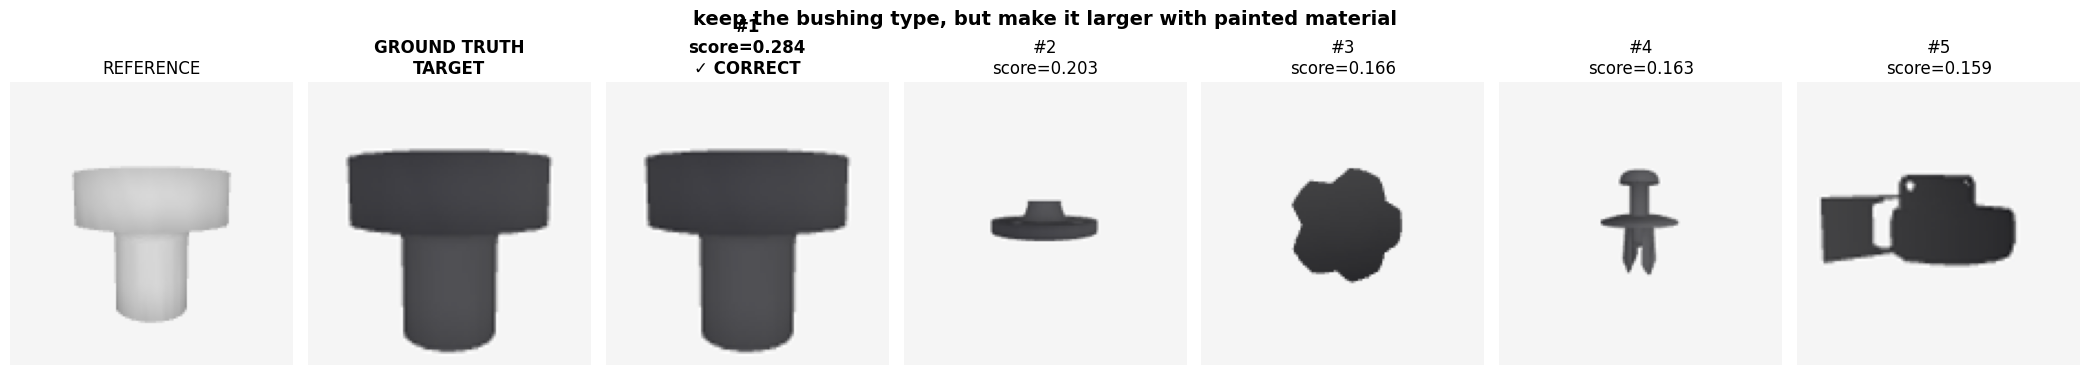


EXAMPLE 2 | Test index = 173
Query: find a similar ring that is larger and painted
Material: painted -> painted
Scale: 1.0 -> 1.3
Ground-truth rank: #1


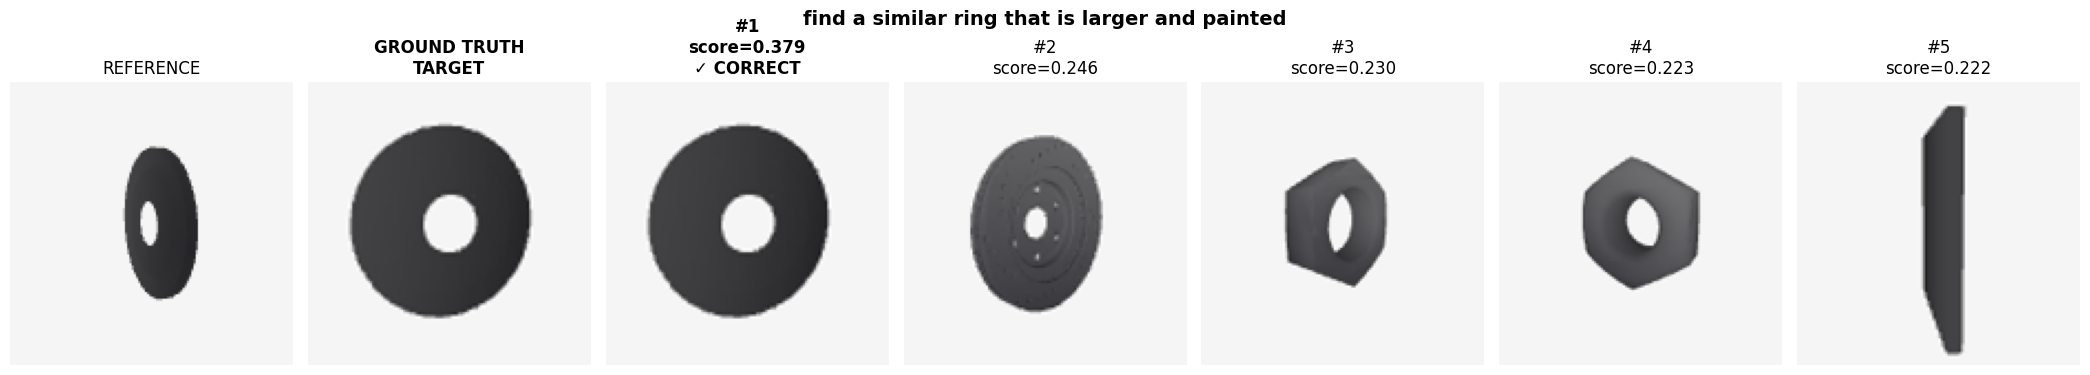


EXAMPLE 3 | Test index = 216
Query: retrieve another spring with a larger size and painted finish
Material: aluminum -> painted
Scale: 1.0 -> 1.15
Ground-truth rank: #1


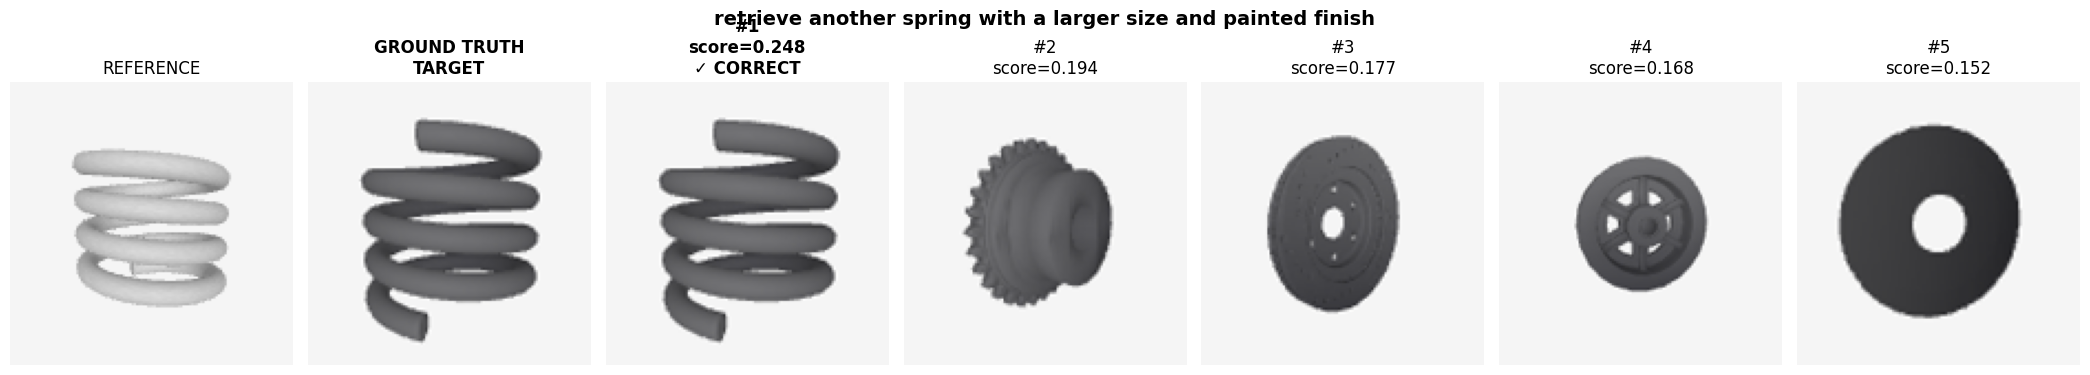


EXAMPLE 4 | Test index = 186
Query: find a similar rivet that is larger and painted
Material: rusted -> painted
Scale: 1.0 -> 1.3
Ground-truth rank: #1


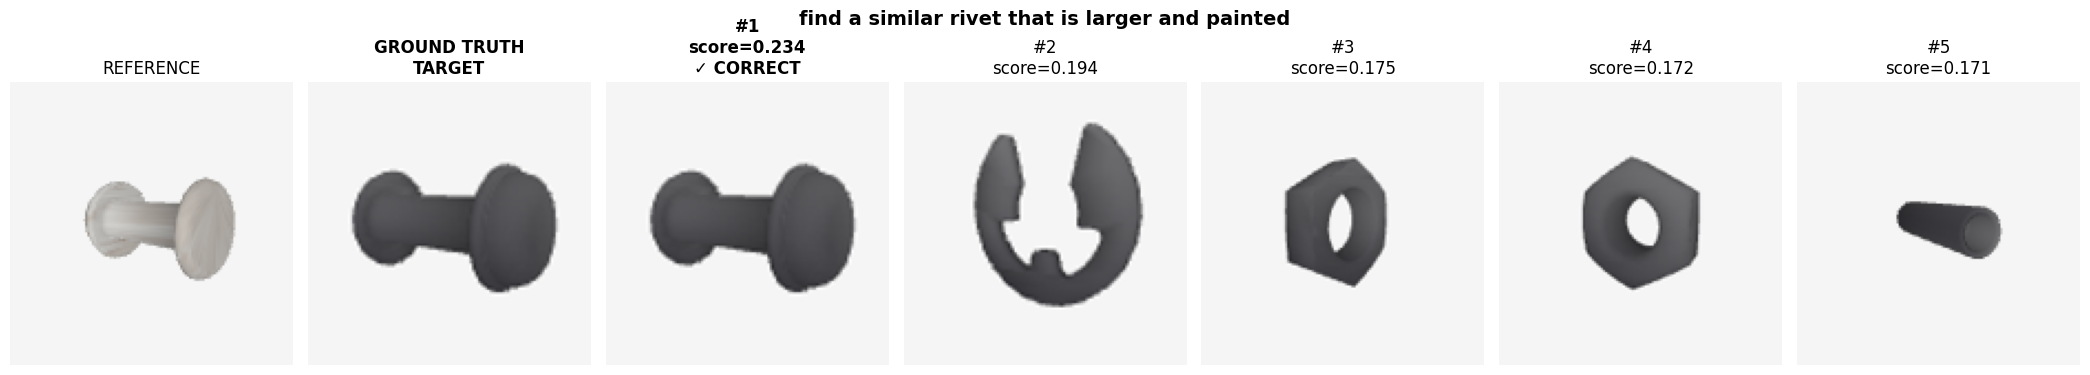


EXAMPLE 5 | Test index = 67
Query: same flange, but larger and brass
Material: metallic -> brass
Scale: 1.0 -> 1.3
Ground-truth rank: #1


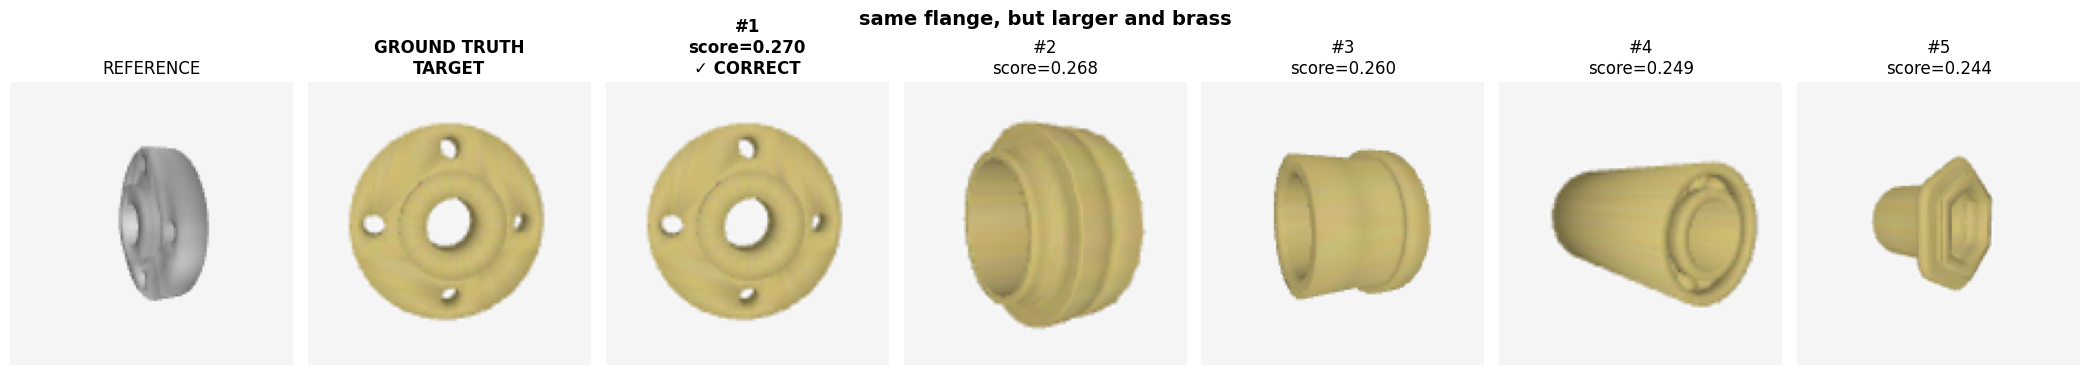


EXAMPLE 6 | Test index = 100
Query: same hinge, but larger and plastic
Material: rusted -> plastic
Scale: 1.0 -> 1.15
Ground-truth rank: #1


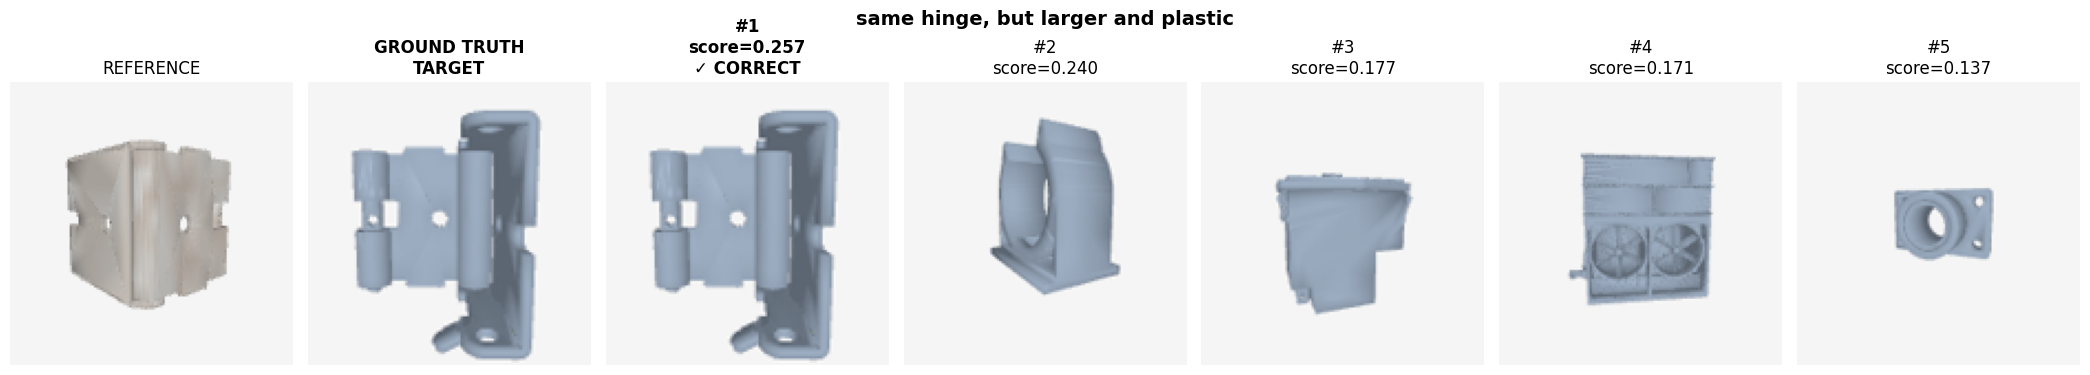

In [ ]:
# ============================================================
# SHOW REAL SUCCESSFUL TEST EXAMPLES
# Reference -> Text Modification -> Ground Truth -> Top-5
#
# Uses the SAME test split used for Recall@K evaluation.
# Only shows examples where:
#   1. A real modification exists
#   2. GT target is visually different from reference
#   3. GT target is retrieved at Rank-1
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

MATERIAL_BONUS = 0.05
TOP_K = 50
N_EXAMPLES = 6


# ------------------------------------------------------------
# Utility: get triplet text safely
# ------------------------------------------------------------

def get_triplet_text(t):
    for k in ["text", "modification_text", "caption", "query"]:
        if k in t:
            return t[k]
    return "Modification query"


# ------------------------------------------------------------
# Utility: check if triplet ACTUALLY changes something
# ------------------------------------------------------------

def has_real_modification(t):

    changed = False

    if "mat_from" in t and "mat_to" in t:
        if t["mat_from"] != t["mat_to"]:
            changed = True

    if "scale_from" in t and "scale_to" in t:
        if abs(float(t["scale_from"]) - float(t["scale_to"])) > 1e-6:
            changed = True

    return changed


# ------------------------------------------------------------
# Prepare test query embeddings
# ------------------------------------------------------------

model_full.eval()

ref_g = test_enc["ref_g"].to(DEVICE)
ref_p = test_enc["ref_p"].to(DEVICE)
txt_g = test_enc["txt_g"].to(DEVICE)

material_id = test_enc["material_id"].to(DEVICE)
size_bin = test_enc["size_bin"].to(DEVICE)
keep_flags = test_enc["keep_flags"].to(DEVICE)

gallery = gallery_g.to(DEVICE)

with torch.no_grad():

    out = model_full(
        ref_g,
        ref_p,
        txt_g,
        material_id,
        size_bin,
        keep_flags
    )

    q = F.normalize(
        out["composed_query"],
        dim=-1
    )

    gallery_norm = F.normalize(
        gallery,
        dim=-1
    )

    sims_full = q @ gallery_norm.T


# ------------------------------------------------------------
# Residual material reranking
# ------------------------------------------------------------

gallery_material = test_enc[
    "material_id"
].to(DEVICE)


successful_examples = []


for i in range(len(test_triplets)):

    triplet = test_triplets[i]

    # ---------------------------------------
    # Skip cases with no actual modification
    # ---------------------------------------

    if not has_real_modification(triplet):
        continue

    # ---------------------------------------
    # Top-K base IC-CIR
    # ---------------------------------------

    candidate_count = min(
        TOP_K,
        gallery.shape[0]
    )

    top_sims, top_idx = torch.topk(
        sims_full[i],
        candidate_count
    )

    # ---------------------------------------
    # Residual material reranker
    # ---------------------------------------

    requested_material = material_id[i]

    candidate_materials = gallery_material[
        top_idx
    ]

    mat_match = (
        candidate_materials
        == requested_material
    ).float()

    material_adjustment = MATERIAL_BONUS * (
        2.0 * mat_match - 1.0
    )

    final_scores = (
        top_sims
        + material_adjustment
    )

    order = torch.argsort(
        final_scores,
        descending=True
    )

    reranked_idx = top_idx[
        order
    ]

    reranked_scores = final_scores[
        order
    ]

    # ---------------------------------------
    # Ground truth target for test item i
    # is gallery item i
    # ---------------------------------------

    true_idx = i

    matches = (
        reranked_idx == true_idx
    ).nonzero(as_tuple=False)

    if len(matches) == 0:
        continue

    gt_rank = int(
        matches[0].item()
    ) + 1

    # We only want beautiful successful examples
    if gt_rank != 1:
        continue

    # ---------------------------------------
    # Make sure ref and target are visually
    # different enough for a useful demo
    # ---------------------------------------

    ref_img = test_enc["imgs"][0][i]
    tgt_img = test_enc["imgs"][1][i]

    ref_arr = np.asarray(
        ref_img.resize((128, 128))
    ).astype(np.float32)

    tgt_arr = np.asarray(
        tgt_img.resize((128, 128))
    ).astype(np.float32)

    visual_diff = np.mean(
        np.abs(ref_arr - tgt_arr)
    )

    # Ignore almost-identical images
    if visual_diff < 2.0:
        continue

    successful_examples.append({
        "index": i,
        "triplet": triplet,
        "gt_rank": gt_rank,
        "reranked_idx": reranked_idx.cpu(),
        "scores": reranked_scores.cpu(),
        "visual_diff": visual_diff
    })


# ------------------------------------------------------------
# Sort by strongest visual difference
# This gives nicer qualitative examples
# ------------------------------------------------------------

successful_examples = sorted(
    successful_examples,
    key=lambda x: x["visual_diff"],
    reverse=True
)


print(
    f"Found {len(successful_examples)} "
    "successful modified Rank-1 examples."
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

examples_to_show = successful_examples[
    :N_EXAMPLES
]


for ex_num, ex in enumerate(
    examples_to_show,
    start=1
):

    i = ex["index"]
    t = ex["triplet"]

    ref_img = test_enc["imgs"][0][i]
    gt_img = test_enc["imgs"][1][i]

    text = get_triplet_text(t)

    top_indices = ex[
        "reranked_idx"
    ][:5]

    top_scores = ex[
        "scores"
    ][:5]

    # --------------------------------------------------------
    # Print metadata
    # --------------------------------------------------------

    print("\n" + "=" * 80)

    print(
        f"EXAMPLE {ex_num} | "
        f"Test index = {i}"
    )

    print(
        "Query:",
        text
    )

    if "mat_from" in t and "mat_to" in t:
        print(
            f"Material: "
            f"{t['mat_from']} -> {t['mat_to']}"
        )

    if "scale_from" in t and "scale_to" in t:
        print(
            f"Scale: "
            f"{t['scale_from']} -> {t['scale_to']}"
        )

    print(
        "Ground-truth rank: #1"
    )

    # --------------------------------------------------------
    # Plot:
    #
    # Reference | GT target | Retrieved #1-#5
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        7,
        figsize=(21, 4)
    )

    # Reference
    axes[0].imshow(
        ref_img
    )
    axes[0].set_title(
        "REFERENCE"
    )
    axes[0].axis("off")

    # Ground truth
    axes[1].imshow(
        gt_img
    )
    axes[1].set_title(
        "GROUND TRUTH\nTARGET",
        fontweight="bold"
    )
    axes[1].axis("off")

    # Top 5
    for j in range(5):

        idx = int(
            top_indices[j]
        )

        score = float(
            top_scores[j]
        )

        candidate_img = test_enc[
            "imgs"
        ][1][idx]

        is_gt = (
            idx == i
        )

        title = (
            f"#{j+1}\n"
            f"score={score:.3f}"
        )

        if is_gt:
            title += "\n✓ CORRECT"

        axes[j + 2].imshow(
            candidate_img
        )

        axes[j + 2].set_title(
            title,
            fontweight=(
                "bold"
                if is_gt
                else "normal"
            )
        )

        axes[j + 2].axis("off")

    fig.suptitle(
        text,
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# If we find too few examples, tell us
# ------------------------------------------------------------

if len(examples_to_show) == 0:

    print("""
No suitable Rank-1 modified examples were found.

Try lowering:

    visual_diff < 2.0

to:

    visual_diff < 0.5

But do NOT manually choose fake examples.
Use examples genuinely produced by the test set.
""")

## 11. Results plot

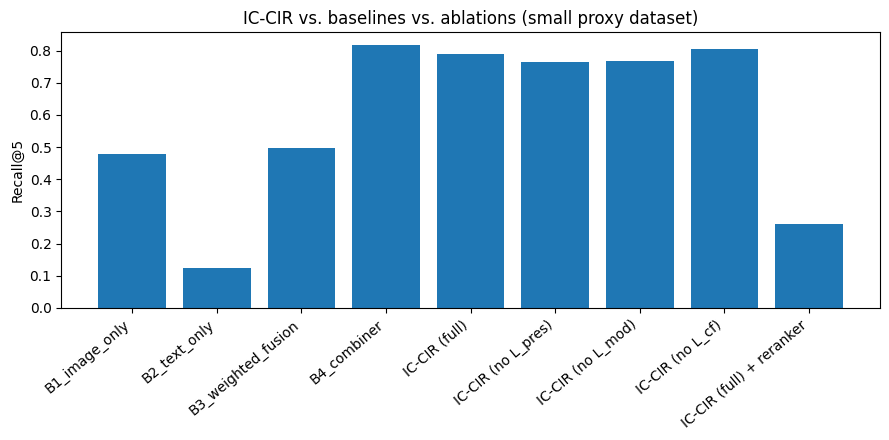

In [ ]:

fig, ax = plt.subplots(figsize=(9, 4.5))
order = results_df.index.tolist()
ax.bar(order, results_df["R@5"])
ax.set_ylabel("Recall@5"); ax.set_title("IC-CIR vs. baselines vs. ablations (small proxy dataset)")
plt.xticks(rotation=40, ha="right"); plt.tight_layout(); plt.show()


# Download

In [ ]:
import shutil
from google.colab import files

# Zip the folder
shutil.make_archive(
    "/content/iccir_final",
    "zip",
    "/content/iccir_final"
)

# Download
files.download("/content/iccir_final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Test + BG  Removal

In [ ]:
# ============================================================
# ONE-TIME IC-CIR INFERENCE SETUP
#
# REQUIREMENT:
# /content/iccir_final/
#     iccir_final_model.pt
#     iccir_gallery.pt
#     iccir_config.json
#     gallery_images/
#
# Run this CELL ONCE.
#
# After that, for every new image simply run:
#
#     run_iccir()
#
# ============================================================

!pip -q install open_clip_torch rembg onnxruntime

import os
import re
import io
import json
import glob

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files
from rembg import remove

import open_clip


# ============================================================
# 1. PATHS
# ============================================================

ROOT = "/content/iccir_final"

MODEL_PATH = os.path.join(
    ROOT,
    "iccir_final_model.pt"
)

GALLERY_PATH = os.path.join(
    ROOT,
    "iccir_gallery.pt"
)

CONFIG_PATH = os.path.join(
    ROOT,
    "iccir_config.json"
)

GALLERY_IMG_DIR = os.path.join(
    ROOT,
    "gallery_images"
)

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)


# ============================================================
# 2. LOAD CONFIG
# ============================================================

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

CLIP_MODEL_NAME = config["clip_model"]
CLIP_PRETRAINED = config["clip_pretrained"]

MATERIAL_LIST = config["materials"]

MATERIAL2ID = {
    m: i
    for i, m in enumerate(MATERIAL_LIST)
}

SIZE_SCALE_CHOICES = config[
    "size_scale_choices"
]

FINAL_MATERIAL_BONUS = config[
    "material_bonus"
]

FINAL_SIZE_WEIGHT = config[
    "size_weight"
]

FINAL_TOP_K = config[
    "top_k"
]


# ============================================================
# 3. LOAD CHECKPOINT INFO
# ============================================================

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

EMBED_DIM = checkpoint.get(
    "embed_dim",
    512
)


# ============================================================
# 4. LOAD OPENCLIP
# ============================================================

clip_model, _, clip_preprocess = (
    open_clip.create_model_and_transforms(
        CLIP_MODEL_NAME,
        pretrained=CLIP_PRETRAINED
    )
)

tokenizer = open_clip.get_tokenizer(
    CLIP_MODEL_NAME
)

clip_model = clip_model.to(
    DEVICE
).eval()

for p in clip_model.parameters():
    p.requires_grad_(False)


# ============================================================
# 5. CLIP FEATURE EXTRACTOR
# ============================================================

class CLIPFeatureExtractor(nn.Module):

    def __init__(self, clip_model):
        super().__init__()
        self.clip = clip_model

    @torch.no_grad()
    def encode_image_tokens(self, images):

        visual = self.clip.visual

        global_feat = self.clip.encode_image(
            images,
            normalize=False
        ).float()

        x = visual.conv1(images)

        x = x.reshape(
            x.shape[0],
            x.shape[1],
            -1
        ).permute(
            0,
            2,
            1
        )

        cls_token = (
            visual.class_embedding
            .to(x.dtype)
        )

        cls_token = (
            cls_token
            + torch.zeros(
                x.shape[0],
                1,
                x.shape[-1],
                dtype=x.dtype,
                device=x.device
            )
        )

        x = torch.cat(
            [cls_token, x],
            dim=1
        )

        x = (
            x
            + visual.positional_embedding
            .to(x.dtype)
        )

        if hasattr(
            visual,
            "patch_dropout"
        ):
            x = visual.patch_dropout(x)

        x = visual.ln_pre(x)

        x = visual.transformer(x)

        patch_tok = x[:, 1:, :]

        patch_tok = visual.ln_post(
            patch_tok
        )

        if visual.proj is not None:
            patch_feat = (
                patch_tok
                @ visual.proj
            )
        else:
            patch_feat = patch_tok

        return (
            global_feat,
            patch_feat.float()
        )

    @torch.no_grad()
    def encode_text(self, tokens):

        return self.clip.encode_text(
            tokens,
            normalize=False
        ).float()


extractor = CLIPFeatureExtractor(
    clip_model
)


# ============================================================
# 6. IC-CIR MODEL DEFINITIONS
# ============================================================

class PartStructureBranch(nn.Module):

    def __init__(
        self,
        dim,
        n_heads=4
    ):
        super().__init__()

        self.query = nn.Parameter(
            torch.randn(
                1,
                1,
                dim
            ) * 0.02
        )

        self.attn = (
            nn.MultiheadAttention(
                dim,
                n_heads,
                batch_first=True
            )
        )

        self.proj = nn.Linear(
            dim,
            dim
        )

    def forward(
        self,
        patch_tokens
    ):

        b = patch_tokens.shape[0]

        q = self.query.expand(
            b,
            -1,
            -1
        )

        out, attn_w = self.attn(
            q,
            patch_tokens,
            patch_tokens
        )

        return (
            self.proj(
                out.squeeze(1)
            ),
            attn_w.squeeze(1)
        )


class ConstraintParser(nn.Module):

    def __init__(
        self,
        text_dim,
        n_materials,
        n_size_bins
    ):

        super().__init__()

        self.material_emb = nn.Embedding(
            n_materials + 1,
            text_dim
        )

        self.size_emb = nn.Embedding(
            n_size_bins + 1,
            text_dim
        )

        self.keep_flag_proj = nn.Linear(
            2,
            text_dim
        )

        self.fuse = nn.Sequential(
            nn.Linear(
                text_dim * 4,
                text_dim
            ),
            nn.GELU(),
            nn.Linear(
                text_dim,
                text_dim
            )
        )

    def forward(
        self,
        clip_text_feat,
        material_id,
        size_bin,
        keep_flags
    ):

        m = self.material_emb(
            material_id
        )

        s = self.size_emb(
            size_bin
        )

        k = self.keep_flag_proj(
            keep_flags.float()
        )

        fused = self.fuse(
            torch.cat(
                [
                    clip_text_feat,
                    m,
                    s,
                    k
                ],
                dim=-1
            )
        )

        return fused


class Disentangler(nn.Module):

    def __init__(
        self,
        dim
    ):

        super().__init__()

        self.names = [
            "structure",
            "material",
            "size"
        ]

        self.heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(
                    dim,
                    dim
                ),
                nn.GELU(),
                nn.Linear(
                    dim,
                    dim
                )
            )
            for _ in self.names
        ])

    def forward(
        self,
        feat
    ):

        return {
            name: head(feat)
            for name, head
            in zip(
                self.names,
                self.heads
            )
        }


class PrototypeComposer(nn.Module):

    def __init__(
        self,
        dim,
        n_prototypes=16
    ):

        super().__init__()

        self.prototypes = nn.Parameter(
            torch.randn(
                n_prototypes,
                dim
            ) * 0.02
        )

        self.q_proj = nn.Linear(
            dim,
            dim
        )

    def forward(
        self,
        feat
    ):

        q = self.q_proj(
            feat
        )

        attn = F.softmax(
            q
            @ self.prototypes.t()
            / (
                feat.shape[-1]
                ** 0.5
            ),
            dim=-1
        )

        return (
            attn
            @ self.prototypes
            + feat
        )


class ICCIR(nn.Module):

    def __init__(
        self,
        dim=EMBED_DIM,
        n_materials=len(
            MATERIAL_LIST
        ),
        n_size_bins=len(
            SIZE_SCALE_CHOICES
        )
    ):

        super().__init__()

        self.part_branch = (
            PartStructureBranch(
                dim
            )
        )

        self.parser = ConstraintParser(
            dim,
            n_materials,
            n_size_bins
        )

        self.disentangler = (
            Disentangler(
                dim
            )
        )

        self.composer_struct = (
            PrototypeComposer(
                dim
            )
        )

        self.composer_material = (
            PrototypeComposer(
                dim
            )
        )

        self.composer_size = (
            PrototypeComposer(
                dim
            )
        )

        self.keep_gate = nn.Sequential(
            nn.Linear(
                dim * 2,
                dim
            ),
            nn.Sigmoid()
        )

        self.fuse_out = nn.Sequential(
            nn.Linear(
                dim * 3,
                dim
            ),
            nn.GELU(),
            nn.Linear(
                dim,
                dim
            )
        )

        self.material_head = nn.Linear(
            dim,
            n_materials
        )

        self.size_head = nn.Linear(
            dim,
            1
        )

    def encode_reference(
        self,
        ref_global,
        ref_patch
    ):

        ref_part, part_attn = (
            self.part_branch(
                ref_patch
            )
        )

        vis_sub = (
            self.disentangler(
                ref_global
                + ref_part
            )
        )

        return (
            vis_sub,
            part_attn
        )

    def forward(
        self,
        ref_global,
        ref_patch,
        text_global,
        material_id,
        size_bin,
        keep_flags
    ):

        vis_sub, part_attn = (
            self.encode_reference(
                ref_global,
                ref_patch
            )
        )

        text_fused = self.parser(
            text_global,
            material_id,
            size_bin,
            keep_flags
        )

        txt_sub = self.disentangler(
            text_fused
        )

        composed_struct = (
            self.composer_struct(
                txt_sub["structure"]
            )
        )

        composed_material = (
            self.composer_material(
                txt_sub["material"]
            )
        )

        composed_size = (
            self.composer_size(
                txt_sub["size"]
            )
        )

        gate = self.keep_gate(
            torch.cat(
                [
                    vis_sub["structure"],
                    composed_struct
                ],
                dim=-1
            )
        )

        kept_struct = (
            gate
            * vis_sub["structure"]
            +
            (
                1 - gate
            )
            * composed_struct
        )

        composed_query = (
            self.fuse_out(
                torch.cat(
                    [
                        kept_struct,
                        composed_material,
                        composed_size
                    ],
                    dim=-1
                )
            )
        )

        composed_query = F.normalize(
            composed_query,
            dim=-1
        )

        return {
            "composed_query":
                composed_query,

            "part_attn":
                part_attn,

            "vis_sub":
                vis_sub,

            "pred_material_logits":
                self.material_head(
                    composed_query
                ),

            "pred_size_delta":
                self.size_head(
                    composed_query
                )
        }


# ============================================================
# 7. LOAD TRAINED IC-CIR WEIGHTS
# ============================================================

model_full = ICCIR(
    dim=EMBED_DIM,
    n_materials=len(
        MATERIAL_LIST
    ),
    n_size_bins=len(
        SIZE_SCALE_CHOICES
    )
).to(DEVICE)

model_full.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model_full.eval()

print("✅ IC-CIR weights loaded")


# ============================================================
# 8. LOAD GALLERY EMBEDDINGS + METADATA
# ============================================================

gallery_data = torch.load(
    GALLERY_PATH,
    map_location="cpu"
)

gallery_g = gallery_data[
    "gallery_g"
].to(DEVICE)

gallery_material = gallery_data[
    "material_id"
].to(DEVICE)

gallery_size_delta = (
    gallery_data[
        "size_delta"
    ].to(DEVICE)
)


# ============================================================
# 9. LOAD GALLERY IMAGES
# ============================================================

gallery_paths = sorted(
    glob.glob(
        os.path.join(
            GALLERY_IMG_DIR,
            "gallery_*.png"
        )
    )
)

gallery_imgs = [
    Image.open(
        p
    ).convert("RGB")
    for p in gallery_paths
]

assert (
    len(gallery_imgs)
    == gallery_g.shape[0]
), (
    f"Gallery image count "
    f"{len(gallery_imgs)} != "
    f"embedding count "
    f"{gallery_g.shape[0]}"
)

print(
    f"✅ Gallery loaded: "
    f"{len(gallery_imgs)} images"
)


# ============================================================
# 10. TEXT QUERY PARSER
# ============================================================

def parse_user_query(
    text
):

    text_l = text.lower()

    detected_material = None

    # Exact names first
    for material in MATERIAL_LIST:

        if (
            material.lower()
            in text_l
        ):
            detected_material = (
                material
            )
            break

    aliases = {
        "metal": "metallic",
        "steel": "metallic",
        "iron": "metallic",

        "plastic": "plastic",

        "aluminium": "aluminum",
        "aluminum": "aluminum",

        "brass": "brass",

        "paint": "painted",
        "painted": "painted",

        "rust": "rusted",
        "rusty": "rusted",
        "rusted": "rusted"
    }

    if detected_material is None:

        for word, mapped in (
            aliases.items()
        ):

            if (
                word in text_l
                and mapped
                in MATERIAL2ID
            ):

                detected_material = (
                    mapped
                )
                break

    # Default
    if detected_material is None:
        detected_material = (
            MATERIAL_LIST[0]
        )

    material_id = MATERIAL2ID[
        detected_material
    ]

    # ---------------- SIZE ----------------

    target_scale = 1.0

    percent_match = re.search(
        r"(\d+(?:\.\d+)?)\s*%",
        text_l
    )

    if percent_match:

        percent = (
            float(
                percent_match.group(1)
            )
            / 100.0
        )

        if any(
            w in text_l
            for w in [
                "larger",
                "bigger",
                "increase"
            ]
        ):

            target_scale = (
                1.0 + percent
            )

        elif any(
            w in text_l
            for w in [
                "smaller",
                "decrease",
                "reduce",
                "reduced"
            ]
        ):

            target_scale = (
                1.0 - percent
            )

    else:

        if any(
            w in text_l
            for w in [
                "much larger",
                "much bigger"
            ]
        ):
            target_scale = 1.30

        elif any(
            w in text_l
            for w in [
                "larger",
                "bigger"
            ]
        ):
            target_scale = 1.15

        elif (
            "much smaller"
            in text_l
        ):
            target_scale = 0.70

        elif (
            "smaller"
            in text_l
        ):
            target_scale = 0.85

    closest_scale = min(
        SIZE_SCALE_CHOICES,
        key=lambda x:
            abs(
                x - target_scale
            )
    )

    size_bin = (
        SIZE_SCALE_CHOICES
        .index(
            closest_scale
        )
    )

    size_delta = (
        closest_scale
        - 1.0
    )

    # Same as training
    keep_flags = [
        0.0,
        0.0
    ]

    return {
        "material":
            detected_material,

        "material_id":
            material_id,

        "target_scale":
            closest_scale,

        "size_bin":
            size_bin,

        "size_delta":
            size_delta,

        "keep_flags":
            keep_flags
    }


# ============================================================
# 11. ENCODING
# ============================================================

def encode_single_image(
    pil_img
):

    img_tensor = (
        clip_preprocess(
            pil_img.convert(
                "RGB"
            )
        )
        .unsqueeze(0)
        .to(DEVICE)
    )

    with torch.inference_mode():

        g, p = (
            extractor
            .encode_image_tokens(
                img_tensor
            )
        )

    return g, p


def encode_single_text(
    text
):

    tokens = tokenizer(
        [text]
    ).to(DEVICE)

    with torch.inference_mode():

        return extractor.encode_text(
            tokens
        )


# ============================================================
# 12. RETRIEVAL
# ============================================================

def retrieve_custom(
    image,
    text,
    display_top=5,
    show=True
):

    if isinstance(
        image,
        str
    ):

        ref_img = Image.open(
            image
        ).convert("RGB")

    else:

        ref_img = image.convert(
            "RGB"
        )

    parsed = parse_user_query(
        text
    )

    ref_g, ref_p = (
        encode_single_image(
            ref_img
        )
    )

    txt_g = encode_single_text(
        text
    )

    material_id = torch.tensor(
        [
            parsed[
                "material_id"
            ]
        ],
        dtype=torch.long,
        device=DEVICE
    )

    size_bin = torch.tensor(
        [
            parsed[
                "size_bin"
            ]
        ],
        dtype=torch.long,
        device=DEVICE
    )

    keep_flags = torch.tensor(
        [
            parsed[
                "keep_flags"
            ]
        ],
        dtype=torch.float32,
        device=DEVICE
    )

    with torch.inference_mode():

        q = model_full(
            ref_g,
            ref_p,
            txt_g,
            material_id,
            size_bin,
            keep_flags
        )[
            "composed_query"
        ]

        sims = (
            F.normalize(
                q,
                dim=-1
            )
            @
            F.normalize(
                gallery_g,
                dim=-1
            ).T
        )[0]

    candidate_count = min(
        FINAL_TOP_K,
        len(gallery_g)
    )

    top_sims, top_idx = (
        torch.topk(
            sims,
            candidate_count
        )
    )

    # --------------------------------------------------------
    # RESIDUAL MATERIAL RERANKING
    # --------------------------------------------------------

    candidate_material = (
        gallery_material[
            top_idx
        ]
    )

    mat_match = (
        candidate_material
        == material_id[0]
    ).float()

    material_adjustment = (
        FINAL_MATERIAL_BONUS
        *
        (
            2.0
            * mat_match
            - 1.0
        )
    )

    final_score = (
        top_sims
        + material_adjustment
    )

    order = torch.argsort(
        final_score,
        descending=True
    )

    final_idx = (
        top_idx[
            order
        ]
    )

    final_scores = (
        final_score[
            order
        ]
    )

    display_n = min(
        display_top,
        len(final_idx)
    )

    result = []

    for rank in range(
        display_n
    ):

        idx = int(
            final_idx[
                rank
            ].item()
        )

        material_name = (
            MATERIAL_LIST[
                int(
                    gallery_material[
                        idx
                    ].item()
                )
            ]
        )

        result.append({
            "rank":
                rank + 1,

            "gallery_index":
                idx,

            "material":
                material_name,

            "score":
                float(
                    final_scores[
                        rank
                    ].item()
                ),

            "image":
                gallery_imgs[
                    idx
                ]
        })

    if show:

        fig, axes = plt.subplots(
            1,
            display_n + 1,
            figsize=(
                3
                * (
                    display_n
                    + 1
                ),
                4
            )
        )

        axes[0].imshow(
            ref_img
        )

        axes[0].set_title(
            "REFERENCE"
        )

        axes[0].axis(
            "off"
        )

        for rank, r in enumerate(
            result
        ):

            axes[
                rank + 1
            ].imshow(
                r["image"]
            )

            axes[
                rank + 1
            ].set_title(
                f"#{rank+1}\n"
                f"{r['material']}\n"
                f"score={r['score']:.3f}"
            )

            axes[
                rank + 1
            ].axis(
                "off"
            )

        fig.suptitle(
            text,
            fontsize=13
        )

        plt.tight_layout()
        plt.show()

    return result


# ============================================================
# 13. CONFIDENCE
# ============================================================

def assess_confidence(
    results,
    min_score=0.30,
    min_margin=0.05,
    min_ratio=1.20
):

    if len(results) < 2:

        return {
            "status":
                "LOW CONFIDENCE"
        }

    scores = np.array(
        [
            r["score"]
            for r in results
        ]
    )

    top1 = scores[0]
    top2 = scores[1]

    margin = (
        top1 - top2
    )

    ratio = (
        top1
        / (
            top2
            + 1e-8
        )
    )

    z_score = (
        (
            top1
            - scores.mean()
        )
        /
        (
            scores.std()
            + 1e-8
        )
    )

    if (
        top1 >= min_score
        and
        margin >= min_margin
        and
        ratio >= min_ratio
    ):

        status = (
            "HIGH CONFIDENCE"
        )

    elif (
        top1 >= min_score
        or
        margin >= min_margin
    ):

        status = (
            "MEDIUM CONFIDENCE"
        )

    else:

        status = (
            "LOW CONFIDENCE"
        )

    return {
        "status":
            status,

        "top1_score":
            float(top1),

        "top2_score":
            float(top2),

        "margin":
            float(margin),

        "ratio":
            float(ratio),

        "z_score":
            float(z_score)
    }


# ============================================================
# 14. BACKGROUND REMOVAL + CROP
# ============================================================

def make_preprocessed_versions(
    img_path
):

    original = Image.open(
        img_path
    ).convert("RGB")

    with open(
        img_path,
        "rb"
    ) as f:

        removed_bytes = remove(
            f.read()
        )

    removed_rgba = (
        Image.open(
            io.BytesIO(
                removed_bytes
            )
        )
        .convert(
            "RGBA"
        )
    )

    white_bg = Image.new(
        "RGBA",
        removed_rgba.size,
        (
            255,
            255,
            255,
            255
        )
    )

    clean = (
        Image.alpha_composite(
            white_bg,
            removed_rgba
        )
        .convert(
            "RGB"
        )
    )

    alpha = (
        removed_rgba
        .getchannel("A")
    )

    bbox = alpha.getbbox()

    if bbox is not None:
        cropped = clean.crop(
            bbox
        )
    else:
        cropped = clean

    pad = max(
        15,
        int(
            0.08
            * max(
                cropped.size
            )
        )
    )

    canvas = Image.new(
        "RGB",
        (
            cropped.width
            + 2 * pad,

            cropped.height
            + 2 * pad
        ),
        "white"
    )

    canvas.paste(
        cropped,
        (
            pad,
            pad
        )
    )

    return {
        "ORIGINAL":
            original,

        "BACKGROUND REMOVED":
            clean,

        "BACKGROUND REMOVED + CROPPED":
            canvas
    }


# ============================================================
# 15. MAIN REUSABLE FUNCTION
#
# Call:
#     run_iccir()
#
# as many times as you want.
# ============================================================

def run_iccir(
    query_text=None,
    display_top=5
):

    print(
        "\nUpload a reference image..."
    )

    uploaded = files.upload()

    if not uploaded:

        print(
            "No image uploaded."
        )

        return

    img_path = next(
        iter(
            uploaded.keys()
        )
    )

    if query_text is None:

        query_text = input(
            "\nEnter modification text: "
        ).strip()

    if not query_text:

        query_text = (
            "same part but plastic"
        )

    versions = (
        make_preprocessed_versions(
            img_path
        )
    )

    all_results = {}

    print(
        "\n"
        + "=" * 70
    )

    print(
        "QUERY:",
        query_text
    )

    print(
        "=" * 70
    )

    for name, image in (
        versions.items()
    ):

        print(
            f"\n{name}"
        )

        results = retrieve_custom(
            image,
            query_text,
            display_top=display_top,
            show=False
        )

        conf = assess_confidence(
            results
        )

        all_results[name] = {
            "image":
                image,

            "results":
                results,

            "confidence":
                conf
        }

        print(
            f"Top1={conf['top1_score']:.4f} | "
            f"Margin={conf['margin']:.4f} | "
            f"Ratio={conf['ratio']:.3f} | "
            f"{conf['status']}"
        )

    # --------------------------------------------------------
    # Pick strongest preprocessing
    # --------------------------------------------------------

    best_name = max(
        all_results,
        key=lambda n: (
            all_results[n][
                "confidence"
            ][
                "top1_score"
            ],

            all_results[n][
                "confidence"
            ][
                "margin"
            ]
        )
    )

    best = all_results[
        best_name
    ]

    results = best[
        "results"
    ]

    conf = best[
        "confidence"
    ]

    print(
        "\n"
        + "=" * 70
    )

    print(
        "BEST PREPROCESSING:",
        best_name
    )

    print(
        "CONFIDENCE:",
        conf["status"]
    )

    print(
        f"Top1 score : "
        f"{conf['top1_score']:.4f}"
    )

    print(
        f"Margin     : "
        f"{conf['margin']:.4f}"
    )

    print(
        f"Ratio      : "
        f"{conf['ratio']:.4f}"
    )

    print(
        "=" * 70
    )

    # --------------------------------------------------------
    # Display ONLY best preprocessing result
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        len(results) + 1,
        figsize=(
            3
            * (
                len(results)
                + 1
            ),
            4
        )
    )

    axes[0].imshow(
        best["image"]
    )

    axes[0].set_title(
        f"REFERENCE\n{best_name}"
    )

    axes[0].axis(
        "off"
    )

    for i, r in enumerate(
        results
    ):

        axes[
            i + 1
        ].imshow(
            r["image"]
        )

        axes[
            i + 1
        ].set_title(
            f"#{i+1}\n"
            f"{r['material']}\n"
            f"{r['score']:.3f}"
        )

        axes[
            i + 1
        ].axis(
            "off"
        )

    fig.suptitle(
        f"{query_text}\n"
        f"{conf['status']}",
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

    return all_results


print("\n" + "=" * 70)
print("✅ IC-CIR READY")
print("=" * 70)
print("""
You do NOT need to run this setup cell again.

For every new image, just run:

    run_iccir()

It will:
1. ask you to upload an image
2. ask for modification text
3. test original image
4. test background-removed image
5. test background-removed + cropped image
6. choose the strongest preprocessing
7. show Top-5 retrievals
8. report confidence

Or skip the text prompt:

    run_iccir("same part but plastic")

    run_iccir("same part but metallic")

    run_iccir("same part but rusted")

    run_iccir("same part but aluminum and 15% larger")
""")

Device: cuda


/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


✅ IC-CIR weights loaded
✅ Gallery loaded: 250 images

✅ IC-CIR READY

You do NOT need to run this setup cell again.

For every new image, just run:

    run_iccir()

It will:
1. ask you to upload an image
2. ask for modification text
3. test original image
4. test background-removed image
5. test background-removed + cropped image
6. choose the strongest preprocessing
7. show Top-5 retrievals
8. report confidence

Or skip the text prompt:

    run_iccir("same part but plastic")

    run_iccir("same part but metallic")

    run_iccir("same part but rusted")

    run_iccir("same part but aluminum and 15% larger")

